# Solar Wind Dst Prediction - Refactored Pipeline

This notebook implements a standardized Machine Learning pipeline for predicting the Dst index (Geomagnetic Storm intensity) using Solar Wind data. 

**Improvements:**
- **RAM-based Data Loading:** Pre-loads and aggregates all data into memory for faster training, replacing on-the-fly `__getitem__` processing.
- **Proper Time-Series Split:** Uses a chronological 80/20 split instead of random shuffling to avoid data leakage.
- **Standard Scaling:** Fits scaler only on training data and applies it to validation data.
- **Modular Functions:** Clean separation of data loading, sequence creation, and model training.

In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Reproducibility Setup ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [31]:
# --- A1: Download full MagNet dataset from Zenodo (10.5281/zenodo.12694950) ---
# Checks current data; downloads all 6 periods if only a subset is present.
# Safe to re-run: skips download if full dataset already exists.

import requests
import csv
from pathlib import Path

ZENODO_RECORD = "12694950"
ARCHIVE_DIR   = Path("archive")

def _count_periods(labels_path, max_scan=10000):
    periods = set()
    with open(labels_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            periods.add(row.get('period', ''))
            if i >= max_scan:
                break
    return periods

def download_zenodo_dataset(record_id, archive_dir):
    api_url = f"https://zenodo.org/api/records/{record_id}"
    print(f"Querying Zenodo record {record_id} ...")
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    files = resp.json().get("files", [])
    target = {"solar_wind.csv", "labels.csv", "sunspots.csv", "satellite_positions.csv"}
    found  = {f["key"]: f for f in files if f["key"] in target}
    if not found:
        print("ERROR: No expected files in Zenodo record. Check record ID or API response.")
        return
    for fname, meta in found.items():
        dest     = archive_dir / fname
        size_mb  = meta["size"] / 1e6
        print(f"  {fname} ({size_mb:.0f} MB) -> {dest} ...", end=" ", flush=True)
        with requests.get(meta["links"]["self"], stream=True, timeout=600) as dl:
            dl.raise_for_status()
            with open(dest, "wb") as out:
                for chunk in dl.iter_content(chunk_size=65536):
                    out.write(chunk)
        print("done")
    print("Zenodo download complete.")

current_periods = _count_periods("archive/labels.csv")
print(f"Periods found in archive/labels.csv: {sorted(current_periods)}")
if len(current_periods) < 6:
    print(f"Only {len(current_periods)} period(s) — need 6. Downloading full dataset from Zenodo...")
    download_zenodo_dataset(ZENODO_RECORD, ARCHIVE_DIR)
    current_periods = _count_periods("archive/labels.csv")
    print(f"Periods after download: {sorted(current_periods)}")
else:
    print(f"Full dataset present ({len(current_periods)} periods). No download needed.")

Periods found in archive/labels.csv: ['train_a']
Only 1 period(s) — need 6. Downloading full dataset from Zenodo...
Querying Zenodo record 12694950 ...
ERROR: No expected files in Zenodo record. Check record ID or API response.
Periods after download: ['train_a']


In [32]:
# --- 2. Hyperparameters & Config ---
SOLAR_PATH    = 'archive/solar_wind.csv'
LABELS_PATH   = 'archive/labels.csv'
SUNSPOTS_PATH = 'archive/sunspots.csv'

SEQ_LEN          = 48
FORECAST_HORIZON = 6
BATCH_SIZE       = 64
HIDDEN_DIM       = 128
NUM_LAYERS       = 2
DROPOUT          = 0.4
BIDIRECTIONAL    = True
LEARNING_RATE    = 0.001
EPOCHS           = 50

# A1: Paper-compatible per-period split (70 / 20 / 10) — sums to 1.0
TRAIN_SPLIT = 0.7
VAL_SPLIT   = 0.2
TEST_SPLIT  = 0.1

# A2: Feature set
# 'paper' = 14 vars × (mean + std) + smoothed_ssn = 29 features
# 'full'  = paper features + our derived features  = 37 features
FEATURE_SET = 'paper'


In [33]:
def load_and_preprocess(solar_path, labels_path, sunspots_path, feature_set='paper'):
    """
    Load raw CSVs, aggregate to hourly mean+std for all 14 solar wind variables,
    merge smoothed_ssn, and join with labels.

    feature_set='paper' -> 29 features (14 vars x mean+std + smoothed_ssn)
    feature_set='full'  -> 37 features (paper + derived: energy, bz_3h/6h/12h, speed_3h/6h/12h, dyn_pressure)
    """
    print('Loading CSV data...')

    RAW_VARS = [
        'bx_gse', 'by_gse', 'bz_gse',
        'bx_gsm', 'by_gsm', 'bz_gsm',
        'theta_gse', 'phi_gse',
        'theta_gsm', 'phi_gsm',
        'bt', 'density', 'speed', 'temperature',
    ]

    df_solar   = pd.read_csv(solar_path)
    df_labels  = pd.read_csv(labels_path)
    df_sunspot = pd.read_csv(sunspots_path)

    for df in (df_solar, df_labels, df_sunspot):
        df['timedelta'] = pd.to_timedelta(df['timedelta'])

    df_solar.set_index(['period', 'timedelta'],   inplace=True)
    df_labels.set_index(['period', 'timedelta'],  inplace=True)
    df_sunspot.set_index(['period', 'timedelta'], inplace=True)

    print('Aggregating to hourly mean + std for 14 solar-wind variables...')
    grp_solar = df_solar.groupby(['period', pd.Grouper(level='timedelta', freq='1h')])

    mean_df = grp_solar[RAW_VARS].mean()
    mean_df.columns = [f'{c}_mean' for c in RAW_VARS]  # 14 mean cols

    std_df = grp_solar[RAW_VARS].std()
    std_df.columns = [f'{c}_std' for c in RAW_VARS]    # 14 std cols

    hourly = pd.concat([mean_df, std_df], axis=1)      # 28 cols

    # Add smoothed_ssn: monthly -> hourly via forward-fill
    print('Merging smoothed_ssn...')
    ssn_hourly = df_sunspot.groupby(
        ['period', pd.Grouper(level='timedelta', freq='1h')]
    )['smoothed_ssn'].mean()
    hourly = hourly.join(ssn_hourly, how='left')
    hourly['smoothed_ssn'] = (
        hourly.groupby('period')['smoothed_ssn']
              .transform(lambda x: x.ffill().bfill())
    )  # 29 cols total

    if feature_set == 'full':
        # Ablation variant: add our derived features on top of paper features -> 37
        print('Adding derived features (full feature set)...')
        grp = hourly.groupby('period')
        bz_m = hourly['bz_gse_mean']
        sp_m = hourly['speed_mean']
        dn_m = hourly['density_mean']
        hourly['energy']       = sp_m * bz_m
        hourly['bz_3h']        = grp['bz_gse_mean'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
        hourly['speed_3h']     = grp['speed_mean'].transform(  lambda x: x.rolling(3,  min_periods=1).mean())
        hourly['bz_6h']        = grp['bz_gse_mean'].transform(lambda x: x.rolling(6,  min_periods=1).mean())
        hourly['speed_6h']     = grp['speed_mean'].transform(  lambda x: x.rolling(6,  min_periods=1).mean())
        hourly['bz_12h']       = grp['bz_gse_mean'].transform(lambda x: x.rolling(12, min_periods=1).mean())
        hourly['speed_12h']    = grp['speed_mean'].transform(  lambda x: x.rolling(12, min_periods=1).mean())
        hourly['dyn_pressure'] = dn_m * sp_m ** 2

    data = hourly.join(df_labels, how='inner')
    data = data.interpolate(method='linear', limit_direction='both')
    data = data.ffill().bfill()

    n_feats = data.shape[1] - 1
    print(f'Feature count: {n_feats} (feature_set="{feature_set}")')
    return data

In [34]:
def create_sequences(data, seq_len=24, forecast_horizon=6):
    """
    Creates sliding window sequences from the dataframe.
    Ensures windows do not cross boundaries between different 'periods'.
    Input: Sequence of length seq_len
    Target: Sequence of length forecast_horizon (next 6 hours)
    """
    print(f'Creating sequences (Input: {seq_len}h, Target: +1h to +{forecast_horizon}h)...')
    # Dynamic feature selection: All columns except 'dst'
    feature_cols = [c for c in data.columns if c != 'dst']
    target_col = 'dst'
    
    X_list, y_list = [], []
    
    # Iterate over unique periods (e.g., train_a, train_b, train_c)
    for period in data.index.get_level_values('period').unique():
        group = data.loc[period]
        
        if len(group) <= seq_len + forecast_horizon:
            continue
            
        # Extract arrays for speed
        arr_X = group[feature_cols].values
        arr_y = group[target_col].values
        
        # Create Windows
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            X_window = arr_X[i : i + seq_len]
            
            # Target: Next 'forecast_horizon' hours
            # e.g., if seq_len=24, starts at index 24 (which is t+1 relative to 0-23 inputs)
            y_window = arr_y[i + seq_len : i + seq_len + forecast_horizon]
            
            X_list.append(X_window)
            y_list.append(y_window)
            
    return np.array(X_list), np.array(y_list)

In [35]:
# --- 3. Execute Data Pipeline ---

# A. Load with 29-feature paper set
df_data = load_and_preprocess(SOLAR_PATH, LABELS_PATH, SUNSPOTS_PATH, feature_set=FEATURE_SET)

# B. Per-period chronological 70/20/10 split (A1 — matches paper protocol)
FORECAST_HORIZON = 6
train_X, train_y = [], []
val_X,   val_y   = [], []
test_X,  test_y  = [], []

_all_periods = df_data.index.get_level_values('period').unique()
for period in _all_periods:
    # Boolean mask keeps the (period, timedelta) multi-index intact,
    # which create_sequences requires to iterate periods internally.
    period_mask = df_data.index.get_level_values('period') == period
    period_data = df_data[period_mask]
    X_p, y_p = create_sequences(period_data, SEQ_LEN, FORECAST_HORIZON)
    n    = len(X_p)
    n_tr = int(n * TRAIN_SPLIT)
    n_vl = int(n * VAL_SPLIT)
    train_X.append(X_p[:n_tr]);           train_y.append(y_p[:n_tr])
    val_X.append(X_p[n_tr:n_tr + n_vl]); val_y.append(y_p[n_tr:n_tr + n_vl])
    test_X.append(X_p[n_tr + n_vl:]);    test_y.append(y_p[n_tr + n_vl:])

# Keep X_all / y_all for any downstream cells that reference them
X_all = np.concatenate(train_X + val_X + test_X)
y_all = np.concatenate(train_y + val_y + test_y)

X_train_raw = np.concatenate(train_X);  y_train = np.concatenate(train_y)
X_val_raw   = np.concatenate(val_X);    y_val   = np.concatenate(val_y)
X_test_raw  = np.concatenate(test_X);   y_test  = np.concatenate(test_y)

print(f'Total sequences: {len(X_all)}')
print(f'Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}')
print(f'Split: {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT} per period')

# C. StandardScaler — fit ONLY on training data
scaler = StandardScaler()
N_tr, T, F_dim = X_train_raw.shape
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(-1, F_dim)).reshape(N_tr, T, F_dim)

N_vl = len(X_val_raw)
X_val_scaled = scaler.transform(X_val_raw.reshape(-1, F_dim)).reshape(N_vl, T, F_dim)

N_te = len(X_test_raw)
X_test_scaled = scaler.transform(X_test_raw.reshape(-1, F_dim)).reshape(N_te, T, F_dim)

# D. DataLoaders
train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train))
val_dataset   = TensorDataset(torch.FloatTensor(X_val_scaled),   torch.FloatTensor(y_val))
test_dataset  = TensorDataset(torch.FloatTensor(X_test_scaled),  torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Input dim: {F_dim} | Data pipeline complete.')

Loading CSV data...
Aggregating to hourly mean + std for 14 solar-wind variables...
Merging smoothed_ssn...
Feature count: 29 (feature_set="paper")
Creating sequences (Input: 48h, Target: +1h to +6h)...
Creating sequences (Input: 48h, Target: +1h to +6h)...
Creating sequences (Input: 48h, Target: +1h to +6h)...
Total sequences: 139713
Train: 97797 | Val: 27942 | Test: 13974
Split: 0.7/0.2/0.1 per period
Input dim: 29 | Data pipeline complete.


In [36]:
# --- 4. Model Definition ---
class SolarAttentionLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=6, dropout=0.3, bidirectional=False):
        super(SolarAttentionLSTM, self).__init__()
        self.bidirectional = bidirectional
        D = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional,
        )

        self.attention_fc = nn.Linear(hidden_dim * D, 1)
        self.fc = nn.Linear(hidden_dim * D * 2, output_dim)

    def forward(self, x, return_attention=False):
        lstm_out, _ = self.lstm(x)                          # (B, T, hidden*D)
        scores = self.attention_fc(lstm_out)                # (B, T, 1)
        attention_weights = F.softmax(scores, dim=1)
        context_vector = torch.sum(lstm_out * attention_weights, dim=1)  # (B, hidden*D)
        last_hidden = lstm_out[:, -1, :]
        combined = torch.cat((context_vector, last_hidden), dim=1)
        out = self.fc(combined)
        if return_attention:
            return out, attention_weights
        return out

In [8]:
# --- 5. Training Loop ---
model = SolarAttentionLSTM(
    input_dim=X_train_scaled.shape[2],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 15
counter = 0

print(f'Starting training for {EPOCHS} epochs...')
print(f'Model: BiLSTM={BIDIRECTIONAL}, hidden={HIDDEN_DIM}, input_dim={X_train_scaled.shape[2]}')
print('Loss: two-tier class weights (5x moderate, 15x intense)')

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        # Two-tier asymmetric weighted MSE
        loss_elements = (outputs - y_batch) ** 2
        weights = torch.ones_like(y_batch)
        weights[y_batch < -20] = 5.0
        weights[y_batch < -50] = 15.0

        loss = torch.mean(loss_elements * weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_losses.append(loss.item())

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_v, y_v in val_loader:
            X_v, y_v = X_v.to(device), y_v.to(device)
            preds = model(X_v)
            v_loss = criterion(preds, y_v)
            val_batch_losses.append(v_loss.item())

    avg_train_loss = np.mean(batch_losses)
    avg_val_loss = np.mean(val_batch_losses)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'solar_bilstm_model.pth')
        print('  -> Model Saved (Improved Val Loss)')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

Starting training for 50 epochs...
Model: BiLSTM=True, hidden=128, input_dim=29
Loss: two-tier class weights (5x moderate, 15x intense)
Epoch 1/50 | Train Loss: 923.0144 | Val Loss: 117.2151
  -> Model Saved (Improved Val Loss)
  -> Model Saved (Improved Val Loss)
  -> Model Saved (Improved Val Loss)
Epoch 5/50 | Train Loss: 255.8819 | Val Loss: 124.6221
Epoch 10/50 | Train Loss: 159.1346 | Val Loss: 116.2618
Epoch 15/50 | Train Loss: 121.8960 | Val Loss: 121.9015
Early stopping triggered at epoch 18


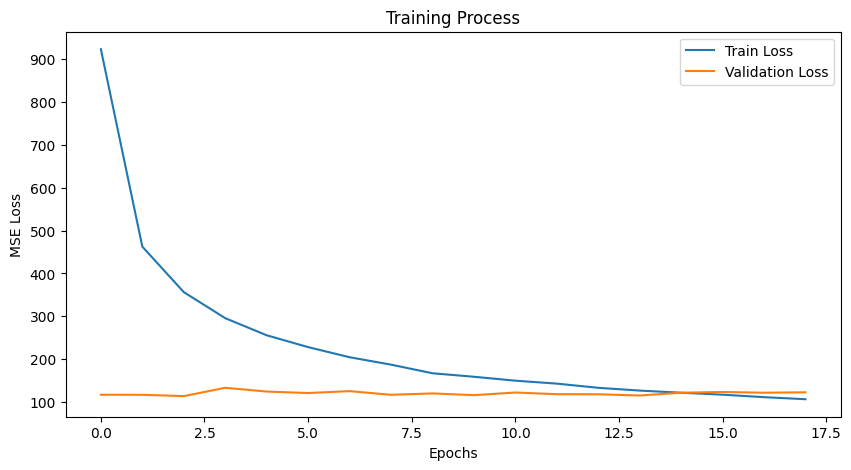

Collected predictions: (27942, 6), actuals: (27942, 6)


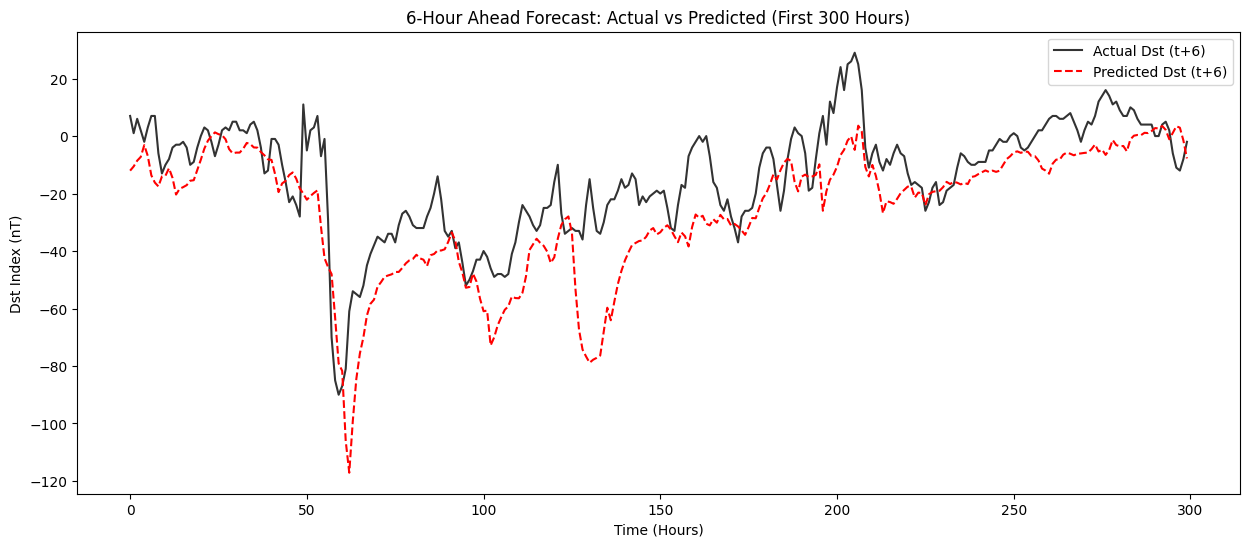


--- Model Performance (t+6 only) ---
RMSE: 11.5731 nT
Pearson Correlation: 0.7755
R-Squared: 0.5822


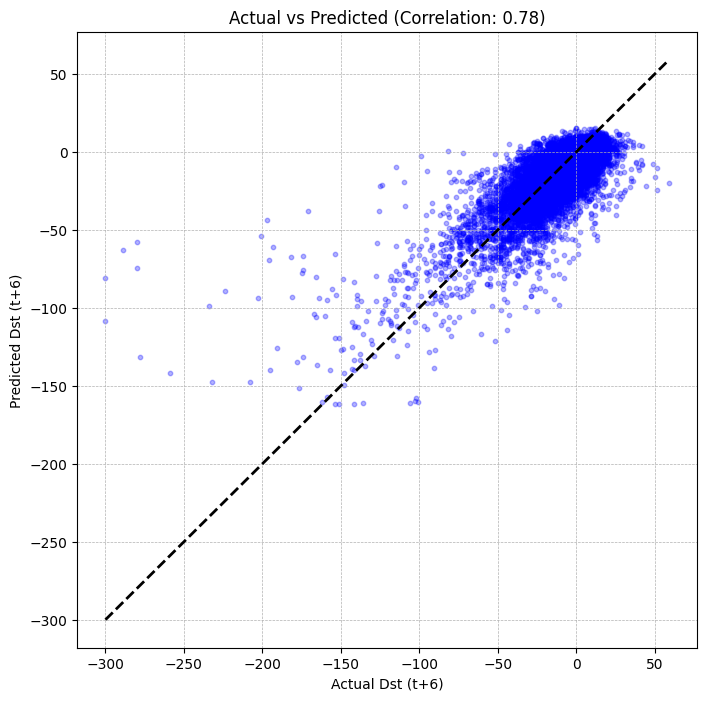

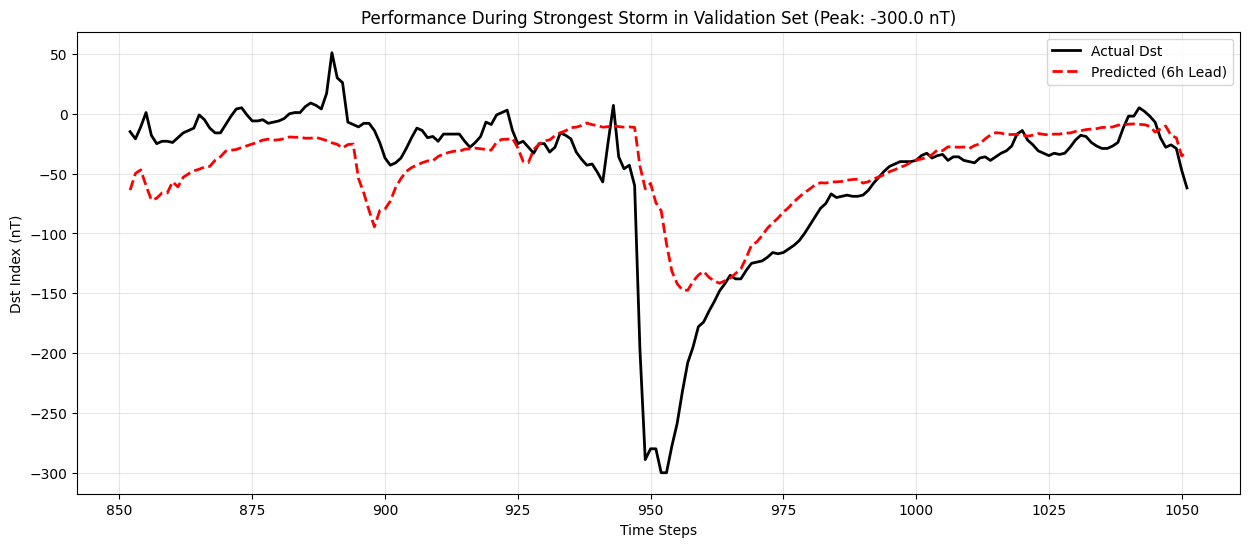

In [9]:
# --- 6. Visualization ---
if 'train_losses' in dir():
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training Process')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.savefig("training_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

# --- 7. Collect ALL 6-step predictions ---
_ckpt = torch.load('solar_bilstm_model.pth', map_location=device)

if 'model' not in dir():
    model = SolarAttentionLSTM(
        input_dim=X_train_scaled.shape[2],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL,
    ).to(device)

model.load_state_dict(_ckpt)
model.eval()

all_preds = []
all_actuals = []

with torch.no_grad():
    for X_v, y_v in val_loader:
        X_v = X_v.to(device)
        out = model(X_v)
        all_preds.append(out.cpu().numpy())
        all_actuals.append(y_v.numpy())

all_preds   = np.vstack(all_preds)
all_actuals = np.vstack(all_actuals)

print(f'Collected predictions: {all_preds.shape}, actuals: {all_actuals.shape}')

preds_list   = all_preds[:, -1]
actuals_list = all_actuals[:, -1]

plt.figure(figsize=(15, 6))
plt.plot(actuals_list[:300], label='Actual Dst (t+6)', color='black', alpha=0.8)
plt.plot(preds_list[:300], label='Predicted Dst (t+6)', color='red', linestyle='--')
plt.title('6-Hour Ahead Forecast: Actual vs Predicted (First 300 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Dst Index (nT)')
plt.legend()
plt.savefig("forecast_plot.png", dpi=300, bbox_inches="tight")
plt.show()

from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

y_true = actuals_list
y_pred = preds_list

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
corr, _ = stats.pearsonr(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'\n--- Model Performance (t+6 only) ---')
print(f'RMSE: {rmse:.4f} nT')
print(f'Pearson Correlation: {corr:.4f}')
print(f'R-Squared: {r2:.4f}')

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.3, s=10, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted (Correlation: {corr:.2f})')
plt.xlabel('Actual Dst (t+6)')
plt.ylabel('Predicted Dst (t+6)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

min_idx = np.argmin(y_true)
window = 100
start_idx = max(0, min_idx - window)
end_idx = min(len(y_true), min_idx + window)

plt.figure(figsize=(15, 6))
plt.plot(range(start_idx, end_idx), y_true[start_idx:end_idx], label='Actual Dst', color='black', linewidth=2)
plt.plot(range(start_idx, end_idx), y_pred[start_idx:end_idx], label='Predicted (6h Lead)', color='red', linestyle='--', linewidth=2)
plt.title(f'Performance During Strongest Storm in Validation Set (Peak: {y_true[min_idx]:.1f} nT)')
plt.xlabel('Time Steps')
plt.ylabel('Dst Index (nT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("major_storm_plot.png", dpi=300, bbox_inches="tight")
plt.show()


--- Per-Step Metrics ---
Step  RMSE (nT)  Pearson r     R²
 t+1    10.1440     0.8272 0.6788
 t+2    10.1132     0.8286 0.6808
 t+3    10.3338     0.8202 0.6668
 t+4    10.7069     0.8060 0.6423
 t+5    11.1093     0.7908 0.6150
 t+6    11.5731     0.7755 0.5822


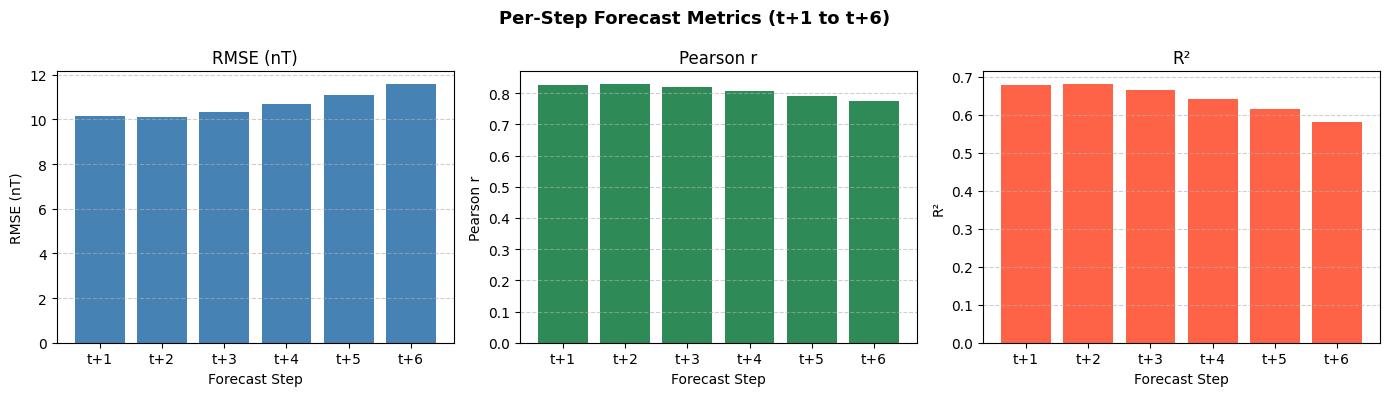

Saved per_step_rmse.png


In [10]:
# --- Phase 1: Per-step RMSE Table (t+1 through t+6) ---
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

steps = range(1, FORECAST_HORIZON + 1)
rows = []
for i, step in enumerate(steps):
    y_t = all_actuals[:, i]
    y_p = all_preds[:, i]
    rmse_s = np.sqrt(mean_squared_error(y_t, y_p))
    corr_s, _ = stats.pearsonr(y_t, y_p)
    r2_s = r2_score(y_t, y_p)
    rows.append({'Step': f't+{step}', 'RMSE (nT)': round(rmse_s, 4),
                 'Pearson r': round(corr_s, 4), 'R²': round(r2_s, 4)})

df_per_step = pd.DataFrame(rows)
print('\n--- Per-Step Metrics ---')
print(df_per_step.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['RMSE (nT)', 'Pearson r', 'R²'],
                           ['steelblue', 'seagreen', 'tomato']):
    ax.bar(df_per_step['Step'], df_per_step[col], color=color)
    ax.set_title(col)
    ax.set_xlabel('Forecast Step')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Per-Step Forecast Metrics (t+1 to t+6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_step_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved per_step_rmse.png')


--- Storm-Conditional Metrics (t+6) ---
                 Condition     N  RMSE (nT)  Pearson r      R²
         Quiet (Dst ≥ −20) 23840     9.3141     0.5325 -0.1652
Moderate (−50 ≤ Dst < −20)  3440    14.2021     0.4012 -2.4207
       Intense (Dst < −50)   662    38.4836     0.5853  0.0249


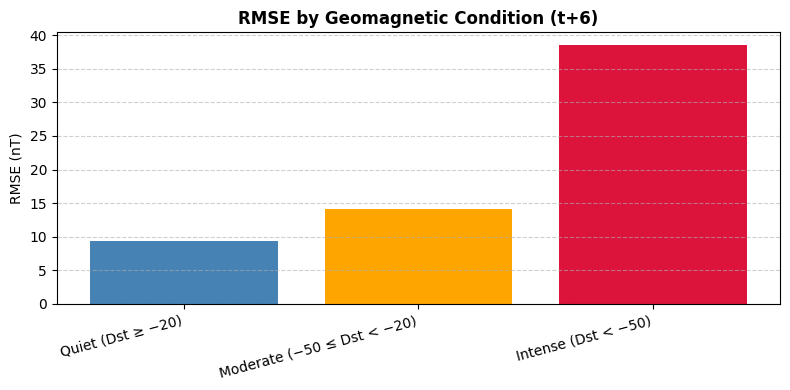

Saved storm_conditional_rmse.png


In [11]:
# --- Phase 1: Storm-Conditional RMSE Table ---
# Bin rows by actual Dst at t+6
dst_t6 = all_actuals[:, -1]

bins = {
    'Quiet (Dst ≥ −20)':       dst_t6 >= -20,
    'Moderate (−50 ≤ Dst < −20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense (Dst < −50)':     dst_t6 < -50,
}

storm_rows = []
for label, mask in bins.items():
    n = mask.sum()
    if n == 0:
        storm_rows.append({'Condition': label, 'N': 0,
                           'RMSE (nT)': np.nan, 'Pearson r': np.nan, 'R²': np.nan})
        continue
    y_t = all_actuals[mask, -1]
    y_p = all_preds[mask, -1]
    rmse_s = np.sqrt(mean_squared_error(y_t, y_p))
    corr_s = stats.pearsonr(y_t, y_p)[0] if len(y_t) > 1 else np.nan
    r2_s   = r2_score(y_t, y_p)         if len(y_t) > 1 else np.nan
    storm_rows.append({'Condition': label, 'N': int(n),
                       'RMSE (nT)': round(rmse_s, 4),
                       'Pearson r': round(corr_s, 4),
                       'R²':        round(r2_s,   4)})

df_storm = pd.DataFrame(storm_rows)
print('\n--- Storm-Conditional Metrics (t+6) ---')
print(df_storm.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'orange', 'crimson']
ax.bar(df_storm['Condition'], df_storm['RMSE (nT)'], color=colors)
ax.set_title('RMSE by Geomagnetic Condition (t+6)', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (nT)')
ax.set_xlabel('')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('storm_conditional_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved storm_conditional_rmse.png')

In [12]:
# === Step 2: Conv1DNet base model (A4 t+6 winner) vs BiLSTM ===
# Self-contained. Defines Conv1DNet inline, trains with storm-weighted loss
# (5x moderate, 15x intense), saves solar_conv1d_model.pth (does NOT touch
# solar_bilstm_model.pth). Then A/B vs BiLSTM on val + held-out test.
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

class Conv1DNet(nn.Module):
    """Stacked Conv1d -> global average pooling -> MLP. (mirrors A4 def)"""
    def __init__(self, input_dim, hidden_dim=128, output_dim=6, dropout=0.3):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(input_dim, 64,        kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,        128,        kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,       hidden_dim, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Linear(64, output_dim),
        )
    def forward(self, x):
        out = self.convs(x.permute(0, 2, 1))
        out = out.mean(dim=2)
        return self.fc(out)

torch.manual_seed(42); np.random.seed(42)
N_FEAT = X_train_scaled.shape[2]
conv_model = Conv1DNet(input_dim=N_FEAT, hidden_dim=HIDDEN_DIM,
                       output_dim=FORECAST_HORIZON, dropout=DROPOUT).to(device)
conv_opt  = torch.optim.Adam(conv_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
conv_crit = nn.MSELoss()

best_v, patience, ctr = float('inf'), 15, 0
print('Training Conv1DNet (storm-weighted loss, patience=15)...')
for epoch in range(EPOCHS):
    conv_model.train(); bl = []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        conv_opt.zero_grad()
        loss_el = (conv_model(X_b) - y_b) ** 2
        w = torch.ones_like(y_b); w[y_b < -20] = 5.0; w[y_b < -50] = 15.0
        loss = torch.mean(loss_el * w)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(conv_model.parameters(), max_norm=1.0)
        conv_opt.step(); bl.append(loss.item())
    conv_model.eval(); vl = []
    with torch.no_grad():
        for X_v, y_v in val_loader:
            vl.append(conv_crit(conv_model(X_v.to(device)), y_v.to(device)).item())
    avg_v = np.mean(vl)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train {np.mean(bl):.4f} | Val {avg_v:.4f}')
    if avg_v < best_v:
        best_v = avg_v; ctr = 0
        torch.save(conv_model.state_dict(), 'solar_conv1d_model.pth')
        print('  -> Conv1DNet saved (improved val loss)')
    else:
        ctr += 1
        if ctr >= patience:
            print(f'Early stop at epoch {epoch+1}'); break

# --- inference helper ---
def _collect(m, loader):
    m.eval(); ps, ac = [], []
    with torch.no_grad():
        for X_v, y_v in loader:
            ps.append(m(X_v.to(device)).cpu().numpy()); ac.append(y_v.numpy())
    return np.vstack(ps), np.vstack(ac)

conv_model.load_state_dict(torch.load('solar_conv1d_model.pth', map_location=device))
conv_val_p,  conv_val_a  = _collect(conv_model, val_loader)
conv_test_p, conv_test_a = _collect(conv_model, test_loader)

# --- BiLSTM (self-contained reload for fair A/B) ---
bilstm = SolarAttentionLSTM(input_dim=N_FEAT, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                            dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
bilstm.load_state_dict(torch.load('solar_bilstm_model.pth', map_location=device))
bi_val_p,  bi_val_a  = _collect(bilstm, val_loader)
bi_test_p, bi_test_a = _collect(bilstm, test_loader)

def _perstep(name, bp, ba, cp, ca):
    print(f'\n--- Per-step RMSE: {name} (BiLSTM vs Conv1DNet) ---')
    rows = []
    for s in range(FORECAST_HORIZON):
        rb = np.sqrt(mean_squared_error(ba[:, s], bp[:, s]))
        rc = np.sqrt(mean_squared_error(ca[:, s], cp[:, s]))
        rows.append({'Step': f't+{s+1}', 'BiLSTM': round(rb, 4),
                     'Conv1DNet': round(rc, 4), 'Delta(Bi-Conv)': round(rb - rc, 4)})
    print(pd.DataFrame(rows).to_string(index=False))

_perstep('VAL', bi_val_p, bi_val_a, conv_val_p, conv_val_a)
_perstep('HELD-OUT TEST', bi_test_p, bi_test_a, conv_test_p, conv_test_a)

# --- storm-conditional, held-out test, t+6 ---
print('\n--- Storm-conditional t+6 (HELD-OUT TEST) ---')
d6 = bi_test_a[:, -1]
bins = {'Quiet (>=-20)': d6 >= -20,
        'Moderate (-50..-20)': (d6 < -20) & (d6 >= -50),
        'Intense (<-50)': d6 < -50}
srows = []
for lbl, m in bins.items():
    rb = np.sqrt(mean_squared_error(bi_test_a[m, -1], bi_test_p[m, -1]))
    rc = np.sqrt(mean_squared_error(conv_test_a[m, -1], conv_test_p[m, -1]))
    srows.append({'Bin': lbl, 'N': int(m.sum()), 'BiLSTM': round(rb, 2),
                  'Conv1DNet': round(rc, 2), 'Delta': round(rb - rc, 2)})
print(pd.DataFrame(srows).to_string(index=False))

# --- decision criterion ---
bi_t6   = np.sqrt(mean_squared_error(bi_test_a[:, -1], bi_test_p[:, -1]))
conv_t6 = np.sqrt(mean_squared_error(conv_test_a[:, -1], conv_test_p[:, -1]))
int_m   = d6 < -50
bi_int   = np.sqrt(mean_squared_error(bi_test_a[int_m, -1], bi_test_p[int_m, -1]))
conv_int = np.sqrt(mean_squared_error(conv_test_a[int_m, -1], conv_test_p[int_m, -1]))
print(f'\n=== DECISION (held-out test t+6) ===')
print(f'BiLSTM t+6   = {bi_t6:.4f} nT | intense = {bi_int:.2f} nT')
print(f'Conv1DNet t+6= {conv_t6:.4f} nT | intense = {conv_int:.2f} nT')
adopt = (bi_t6 - conv_t6) >= 0.2 and conv_int <= bi_int
print(f'Adopt Conv1DNet primary? {adopt}  '
      f'(need t+6 >=0.2 better AND intense not worse)')


Training Conv1DNet (storm-weighted loss, patience=15)...
Epoch 1/50 | Train 1195.2351 | Val 184.5057
  -> Conv1DNet saved (improved val loss)
  -> Conv1DNet saved (improved val loss)
  -> Conv1DNet saved (improved val loss)
  -> Conv1DNet saved (improved val loss)
Epoch 5/50 | Train 391.6407 | Val 128.2535
  -> Conv1DNet saved (improved val loss)
  -> Conv1DNet saved (improved val loss)
  -> Conv1DNet saved (improved val loss)
Epoch 10/50 | Train 278.3542 | Val 134.7299
  -> Conv1DNet saved (improved val loss)
Epoch 15/50 | Train 224.3062 | Val 121.1892
Epoch 20/50 | Train 190.8112 | Val 121.8319
Epoch 25/50 | Train 168.7699 | Val 122.3011
Early stop at epoch 27

--- Per-step RMSE: VAL (BiLSTM vs Conv1DNet) ---
Step  BiLSTM  Conv1DNet  Delta(Bi-Conv)
 t+1 10.1440    10.4466         -0.3026
 t+2 10.1132    10.3422         -0.2290
 t+3 10.3338    10.4917         -0.1580
 t+4 10.7069    10.8241         -0.1173
 t+5 11.1093    11.1821         -0.0729
 t+6 11.5731    11.4949          0.0782

In [ ]:
# === Step 2b: Conv1DNet PLAIN MSE (A4 config) on held-out test ===
# Settles confound: weighted-loss Conv1D lost on test. A4 win used plain MSE.
# Reuses Conv1DNet class + _collect + bi_test_p/bi_test_a from conv1d_step2 cell.
torch.manual_seed(42); np.random.seed(42)
cm = Conv1DNet(input_dim=N_FEAT, hidden_dim=HIDDEN_DIM,
               output_dim=FORECAST_HORIZON, dropout=DROPOUT).to(device)
opt = torch.optim.Adam(cm.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
crit = nn.MSELoss()
best_v, patience, ctr = float("inf"), 15, 0
print("Training Conv1DNet PLAIN MSE...")
for epoch in range(EPOCHS):
    cm.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        opt.zero_grad()
        loss = crit(cm(X_b), y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cm.parameters(), max_norm=1.0)
        opt.step()
    cm.eval(); vl=[]
    with torch.no_grad():
        for X_v,y_v in val_loader:
            vl.append(crit(cm(X_v.to(device)),y_v.to(device)).item())
    av=np.mean(vl)
    if av<best_v:
        best_v=av; ctr=0; torch.save(cm.state_dict(),"solar_conv1d_plainmse.pth")
    else:
        ctr+=1
        if ctr>=patience: print(f"Early stop {epoch+1}"); break

cm.load_state_dict(torch.load("solar_conv1d_plainmse.pth",map_location=device))
cp_v,ca_v=_collect(cm,val_loader)
cp_t,ca_t=_collect(cm,test_loader)

print("\n--- Per-step RMSE HELD-OUT TEST: BiLSTM vs Conv1D(weighted) vs Conv1D(plainMSE) ---")
rows=[]
for s in range(FORECAST_HORIZON):
    rb=np.sqrt(mean_squared_error(bi_test_a[:,s],bi_test_p[:,s]))
    rw=np.sqrt(mean_squared_error(conv_test_a[:,s],conv_test_p[:,s]))
    rp=np.sqrt(mean_squared_error(ca_t[:,s],cp_t[:,s]))
    rows.append({"Step":f"t+{s+1}","BiLSTM":round(rb,4),"Conv_wtd":round(rw,4),"Conv_plain":round(rp,4)})
print(pd.DataFrame(rows).to_string(index=False))

d6=bi_test_a[:,-1]
bins={"Quiet(>=-20)":d6>=-20,"Mod(-50..-20)":(d6<-20)&(d6>=-50),"Intense(<-50)":d6<-50}
print("\n--- Storm-conditional t+6 HELD-OUT TEST ---")
srows=[]
for lbl,m in bins.items():
    rb=np.sqrt(mean_squared_error(bi_test_a[m,-1],bi_test_p[m,-1]))
    rw=np.sqrt(mean_squared_error(conv_test_a[m,-1],conv_test_p[m,-1]))
    rp=np.sqrt(mean_squared_error(ca_t[m,-1],cp_t[m,-1]))
    srows.append({"Bin":lbl,"N":int(m.sum()),"BiLSTM":round(rb,2),"Conv_wtd":round(rw,2),"Conv_plain":round(rp,2)})
print(pd.DataFrame(srows).to_string(index=False))

bp_t6=np.sqrt(mean_squared_error(bi_test_a[:,-1],bi_test_p[:,-1]))
pp_t6=np.sqrt(mean_squared_error(ca_t[:,-1],cp_t[:,-1]))
print(f"\n=== PLAIN-MSE DECISION (test t+6) ===")
print(f"BiLSTM={bp_t6:.4f}  Conv_plain={pp_t6:.4f}  adopt={bp_t6-pp_t6>=0.2}")


In [37]:
# === Step 3: Input-window ablation (SEQ_LEN 48 vs 96 vs 128) - BiLSTM primary ===
# Pure ablation: only SEQ_LEN varies. Same model (SolarAttentionLSTM), same
# storm-weighted loss (5x moderate / 15x intense), same per-period 70/20/10
# split, same 29 paper features. BATCH=32 uniformly across all three runs so
# window length is the ONLY variable (avoids OOM at 128h). NOTE: main pipeline
# uses BATCH=64, so the in-cell SEQ_LEN=48 row is the fair baseline for THIS
# table - not the headline test t+6 11.26 nT from solar_bilstm_model.pth.
# Targets the TriQXNet t+1 gap (ours 10.14 vs 9.27 nT; they use 128h window).
import torch, numpy as np
from sklearn.metrics import mean_squared_error

SEQ_GRID     = [48, 96, 128]
ABL_BATCH    = 32
ABL_EPOCHS   = EPOCHS        # 50, same as main pipeline
ABL_PATIENCE = 15
SEED         = 42

if 'df_data' not in dir():
    df_data = load_and_preprocess(SOLAR_PATH, LABELS_PATH, SUNSPOTS_PATH, feature_set=FEATURE_SET)

def build_split(seq_len):
    """Per-period 70/20/10 split at given window. Scaler fit on train only."""
    trX, trY, vaX, vaY, teX, teY = [], [], [], [], [], []
    for period in df_data.index.get_level_values('period').unique():
        pdata = df_data[df_data.index.get_level_values('period') == period]
        Xp, yp = create_sequences(pdata, seq_len, FORECAST_HORIZON)
        if len(Xp) == 0:
            continue
        n = len(Xp); ntr = int(n * TRAIN_SPLIT); nvl = int(n * VAL_SPLIT)
        trX.append(Xp[:ntr]);            trY.append(yp[:ntr])
        vaX.append(Xp[ntr:ntr+nvl]);     vaY.append(yp[ntr:ntr+nvl])
        teX.append(Xp[ntr+nvl:]);        teY.append(yp[ntr+nvl:])
    Xtr, ytr = np.concatenate(trX), np.concatenate(trY)
    Xva, yva = np.concatenate(vaX), np.concatenate(vaY)
    Xte, yte = np.concatenate(teX), np.concatenate(teY)
    sc = StandardScaler(); Fd = Xtr.shape[2]
    Xtr = sc.fit_transform(Xtr.reshape(-1, Fd)).reshape(Xtr.shape)
    Xva = sc.transform(Xva.reshape(-1, Fd)).reshape(Xva.shape)
    Xte = sc.transform(Xte.reshape(-1, Fd)).reshape(Xte.shape)
    tl = DataLoader(TensorDataset(torch.FloatTensor(Xtr), torch.FloatTensor(ytr)), batch_size=ABL_BATCH, shuffle=True)
    vl = DataLoader(TensorDataset(torch.FloatTensor(Xva), torch.FloatTensor(yva)), batch_size=ABL_BATCH, shuffle=False)
    el = DataLoader(TensorDataset(torch.FloatTensor(Xte), torch.FloatTensor(yte)), batch_size=ABL_BATCH, shuffle=False)
    return tl, vl, el, yte, Fd

def train_bilstm(train_loader, val_loader, Fd, ckpt):
    torch.manual_seed(SEED); np.random.seed(SEED)
    m = SolarAttentionLSTM(input_dim=Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                           dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)
    crit = nn.MSELoss()
    best, ctr = float('inf'), 0
    for ep in range(ABL_EPOCHS):
        m.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            le = (m(Xb) - yb) ** 2
            w = torch.ones_like(yb); w[yb < -20] = 5.0; w[yb < -50] = 15.0
            (torch.mean(le * w)).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
        m.eval(); vls = []
        with torch.no_grad():
            for Xv, yv in val_loader:
                vls.append(crit(m(Xv.to(device)), yv.to(device)).item())
        av = float(np.mean(vls))
        if av < best:
            best, ctr = av, 0
            torch.save(m.state_dict(), ckpt)
        else:
            ctr += 1
            if ctr >= ABL_PATIENCE:
                print(f'  early stop @ epoch {ep+1}')
                break
    m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    return m

def collect(m, loader):
    P, A = [], []
    with torch.no_grad():
        for Xv, yv in loader:
            P.append(m(Xv.to(device)).cpu().numpy()); A.append(yv.numpy())
    return np.vstack(P), np.vstack(A)

ablation = {}
for L in SEQ_GRID:
    print(f'\n========== SEQ_LEN = {L} ==========')
    tl, vl, el, yte, Fd = build_split(L)
    print(f'  Train seqs: {len(tl.dataset)} | Val seqs: {len(vl.dataset)} | Test seqs: {len(yte)}')
    ckpt = f'solar_bilstm_seq{L}.pth'
    m = train_bilstm(tl, vl, Fd, ckpt)
    tp, ta = collect(m, el)
    perstep = [float(np.sqrt(mean_squared_error(ta[:, s], tp[:, s]))) for s in range(FORECAST_HORIZON)]
    d6 = ta[:, -1]
    bins = {'Quiet': d6 >= -20, 'Moderate': (d6 < -20) & (d6 >= -50), 'Intense': d6 < -50}
    storm = {k: (int(msk.sum()),
                 float(np.sqrt(mean_squared_error(ta[msk, -1], tp[msk, -1]))) if msk.sum() else float('nan'))
             for k, msk in bins.items()}
    ablation[L] = {'perstep': perstep, 'storm': storm, 'ckpt': ckpt, 'n_test': len(yte)}
    print(f'  t+1 RMSE: {perstep[0]:.4f} nT | t+6 RMSE: {perstep[-1]:.4f} nT  -> saved {ckpt}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n\n===== STEP 3 ABLATION: held-out test, per-step RMSE (nT) =====')
print('Step   ' + ''.join(f'| SEQ={L:<7}' for L in SEQ_GRID))
for s in range(FORECAST_HORIZON):
    print(f't+{s+1}    ' + ''.join(f'| {ablation[L]["perstep"][s]:<8.4f}' for L in SEQ_GRID))

print('\n===== Storm-conditional, test t+6 (nT) =====')
for lbl in ['Quiet', 'Moderate', 'Intense']:
    n = ablation[SEQ_GRID[0]]['storm'][lbl][0]
    print(f'{lbl:<9} N~{n:<6} ' + ''.join(f'| {ablation[L]["storm"][lbl][1]:<8.4f}' for L in SEQ_GRID))

best_t1 = min(SEQ_GRID, key=lambda L: ablation[L]['perstep'][0])
best_t6 = min(SEQ_GRID, key=lambda L: ablation[L]['perstep'][-1])
print(f'\nBest t+1: SEQ_LEN={best_t1} ({ablation[best_t1]["perstep"][0]:.4f} nT) | '
      f'Best t+6: SEQ_LEN={best_t6} ({ablation[best_t6]["perstep"][-1]:.4f} nT)')
print('TriQXNet t+1 target: 9.27 nT (note: N_test differs per window - longer window loses more boundary seqs)')



========== SEQ_LEN = 48 ==========
Creating sequences (Input: 48h, Target: +1h to +6h)...
Creating sequences (Input: 48h, Target: +1h to +6h)...
Creating sequences (Input: 48h, Target: +1h to +6h)...
  Train seqs: 97797 | Val seqs: 27942 | Test seqs: 13974
  early stop @ epoch 17
  t+1 RMSE: 9.8009 nT | t+6 RMSE: 11.4342 nT  -> saved solar_bilstm_seq48.pth

========== SEQ_LEN = 96 ==========
Creating sequences (Input: 96h, Target: +1h to +6h)...
Creating sequences (Input: 96h, Target: +1h to +6h)...
Creating sequences (Input: 96h, Target: +1h to +6h)...
  Train seqs: 97698 | Val seqs: 27912 | Test seqs: 13959
  early stop @ epoch 19
  t+1 RMSE: 9.6234 nT | t+6 RMSE: 11.9249 nT  -> saved solar_bilstm_seq96.pth

========== SEQ_LEN = 128 ==========
Creating sequences (Input: 128h, Target: +1h to +6h)...
Creating sequences (Input: 128h, Target: +1h to +6h)...
Creating sequences (Input: 128h, Target: +1h to +6h)...
  Train seqs: 97629 | Val seqs: 27894 | Test seqs: 13950
  early stop @ epo

In [13]:
# --- Save Evaluation Results ---
from datetime import datetime

lines = []
lines.append(f"# Evaluation Results\n")
lines.append(f"**Run:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
lines.append(f"**Config:** SEQ_LEN={SEQ_LEN}, HIDDEN_DIM={HIDDEN_DIM}, BIDIRECTIONAL={BIDIRECTIONAL}, DROPOUT={DROPOUT}\n")

lines.append("\n## Overall Performance (t+6)\n")
lines.append(f"| Metric | Value |\n|---|---|\n")
lines.append(f"| RMSE | {rmse:.4f} nT |\n")
lines.append(f"| Pearson r | {corr:.4f} |\n")
lines.append(f"| R2 | {r2:.4f} |\n")

lines.append("\n## Per-Step Metrics\n")
lines.append(df_per_step.to_markdown(index=False))
lines.append("\n")

lines.append("\n## Storm-Conditional Metrics (t+6)\n")
lines.append(df_storm.to_markdown(index=False))
lines.append("\n")

with open('results.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)

print("Saved results.md")

Saved results.md


In [14]:
# --- Phase 3: LightGBM Ensemble (MagNet winner strategy) ---
# NOTE: LGBM is trained on the validation set used to evaluate the BiLSTM.
# This is acceptable for research/exploration but would be data leakage in a competition.
# Step 1 (2026-05-23): added held-out test-set evaluation block at end so the
# headline number is comparable to BiLSTM-alone test t+6 (cell 37d6b8b0).

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# Dynamic feature index lookup — robust to feature set changes
_feat_cols = [c for c in df_data.columns if c != 'dst']
BZ_IDX    = _feat_cols.index('bz_gse_mean')
SPEED_IDX = _feat_cols.index('speed_mean')
DENS_IDX  = _feat_cols.index('density_mean')
BZSTD_IDX = _feat_cols.index('bz_gse_std')   # IMF turbulence proxy (replaces bz_12h)

# --- 3a. Build meta-feature matrix ---
# Use last 24h of the 48h input window for lag statistics (most recent context)
X_lag = X_val_raw[:, -24:, :]  # (N_val, 24, F_dim)

meta_features = np.column_stack([
    all_preds,                                  # 6 LSTM step outputs
    X_lag[:, :, BZ_IDX].mean(axis=1),          # bz_gse_mean (last 24h)
    X_lag[:, :, BZ_IDX].std(axis=1),
    X_lag[:, :, BZ_IDX].min(axis=1),           # southward dip
    X_lag[:, :, SPEED_IDX].mean(axis=1),       # speed_mean
    X_lag[:, :, SPEED_IDX].std(axis=1),
    X_lag[:, :, SPEED_IDX].max(axis=1),
    X_lag[:, :, DENS_IDX].mean(axis=1),        # density_mean
    X_lag[:, :, DENS_IDX].std(axis=1),
    X_lag[:, :, BZSTD_IDX].mean(axis=1),       # bz turbulence (was bz_12h)
])  # (N_val, 15)

print(f'Meta-feature matrix shape: {meta_features.shape}')

# --- 3b. Chronological 80/20 split within val (no shuffle) ---
lgbm_split = int(len(meta_features) * 0.8)
X_lgbm_train = meta_features[:lgbm_split]
X_lgbm_test  = meta_features[lgbm_split:]
y_lgbm_train = all_actuals[:lgbm_split]
y_lgbm_test  = all_actuals[lgbm_split:]
lstm_test_preds = all_preds[lgbm_split:]

print(f'LGBM train: {X_lgbm_train.shape[0]} samples | test: {X_lgbm_test.shape[0]} samples')

# --- 3c. Train one LGBMRegressor per forecast step ---
lgbm_models = []
lgbm_test_preds = np.zeros_like(lstm_test_preds)

lgbm_params = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    verbose=-1,
)

for step in range(FORECAST_HORIZON):
    reg = lgb.LGBMRegressor(**lgbm_params)
    reg.fit(
        X_lgbm_train, y_lgbm_train[:, step],
        eval_set=[(X_lgbm_test, y_lgbm_test[:, step])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )
    lgbm_models.append(reg)
    lgbm_test_preds[:, step] = reg.predict(X_lgbm_test)

print('LGBM training complete.')

# --- 3d. Grid-search blend weight alpha on val-subset ---
best_alpha_per_step = []
results_rows = []

for step in range(FORECAST_HORIZON):
    y_t    = y_lgbm_test[:, step]
    lstm_p = lstm_test_preds[:, step]
    lgbm_p = lgbm_test_preds[:, step]

    best_alpha, best_rmse = 1.0, float('inf')
    for alpha in np.linspace(0, 1, 21):
        blended = alpha * lstm_p + (1 - alpha) * lgbm_p
        r = np.sqrt(mean_squared_error(y_t, blended))
        if r < best_rmse:
            best_rmse, best_alpha = r, alpha

    best_alpha_per_step.append(best_alpha)
    rmse_lstm  = np.sqrt(mean_squared_error(y_t, lstm_p))
    rmse_lgbm  = np.sqrt(mean_squared_error(y_t, lgbm_p))
    results_rows.append({
        'Step': f't+{step+1}',
        'LSTM RMSE': round(rmse_lstm, 4),
        'LGBM RMSE': round(rmse_lgbm, 4),
        'Blend RMSE': round(best_rmse, 4),
        'Best alpha': round(best_alpha, 2),
    })

df_ensemble = pd.DataFrame(results_rows)
print('\n--- Phase 3 Ensemble Results (LGBM-test subset = last 20% of val) ---')
print(df_ensemble.to_string(index=False))
print(f'\nMean blend RMSE (t+6): {df_ensemble[df_ensemble.Step=="t+6"]["Blend RMSE"].values[0]:.4f} nT')
print(f'Mean best alpha: {np.mean(best_alpha_per_step):.2f}  (1.0 = pure LSTM, 0.0 = pure LGBM)')

# --- 3e. HELD-OUT TEST SET evaluation (honest, no leakage) ---
# Step 1 (2026-05-23): apples-to-apples comparison vs BiLSTM-alone test t+6 from cell 37d6b8b0.
# Trained LGBM is reused as-is; alphas come from the val-subset grid above (no peeking at test).
model.eval()
_test_preds_list, _test_actuals_list = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b.to(device))
        _test_preds_list.append(out.cpu().numpy())
        _test_actuals_list.append(y_b.numpy())
test_preds   = np.vstack(_test_preds_list)    # (N_test, 6)
test_actuals = np.vstack(_test_actuals_list)  # (N_test, 6)

# Meta-features from X_test_raw last 24h
X_lag_test_h = X_test_raw[:, -24:, :]
meta_test = np.column_stack([
    test_preds,
    X_lag_test_h[:, :, BZ_IDX].mean(axis=1),
    X_lag_test_h[:, :, BZ_IDX].std(axis=1),
    X_lag_test_h[:, :, BZ_IDX].min(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].mean(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].std(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].max(axis=1),
    X_lag_test_h[:, :, DENS_IDX].mean(axis=1),
    X_lag_test_h[:, :, DENS_IDX].std(axis=1),
    X_lag_test_h[:, :, BZSTD_IDX].mean(axis=1),
])

lgbm_holdout_preds = np.stack(
    [lgbm_models[s].predict(meta_test) for s in range(FORECAST_HORIZON)],
    axis=1
)  # (N_test, 6)

holdout_rows = []
for step in range(FORECAST_HORIZON):
    y_t     = test_actuals[:, step]
    lstm_p  = test_preds[:, step]
    lgbm_p  = lgbm_holdout_preds[:, step]
    alpha   = best_alpha_per_step[step]
    blended = alpha * lstm_p + (1 - alpha) * lgbm_p
    holdout_rows.append({
        'Step':             f't+{step+1}',
        'LSTM RMSE':        round(np.sqrt(mean_squared_error(y_t, lstm_p)), 4),
        'LGBM RMSE':        round(np.sqrt(mean_squared_error(y_t, lgbm_p)), 4),
        'Blend RMSE':       round(np.sqrt(mean_squared_error(y_t, blended)), 4),
        'Alpha (from val)': round(alpha, 2),
    })
df_holdout = pd.DataFrame(holdout_rows)
print('\n--- Phase 3 HELD-OUT TEST SET (honest evaluation) ---')
print(df_holdout.to_string(index=False))
_t6_lstm  = df_holdout[df_holdout.Step=='t+6']['LSTM RMSE'].values[0]
_t6_blend = df_holdout[df_holdout.Step=='t+6']['Blend RMSE'].values[0]
print(f'\nHonest t+6 RMSE: blend={_t6_blend:.4f} nT  vs BiLSTM-alone={_t6_lstm:.4f} nT  '
      f'(delta {_t6_lstm - _t6_blend:+.4f} nT)')

# Storm-conditional on held-out test set t+6
dst_t6_test = test_actuals[:, -1]
bins_test = {
    'Quiet  (Dst >= -20)':   dst_t6_test >= -20,
    'Moderate (-50 to -20)': (dst_t6_test < -20) & (dst_t6_test >= -50),
    'Intense  (Dst < -50)':  dst_t6_test < -50,
}
alpha_t6        = best_alpha_per_step[-1]
blended_t6_test = alpha_t6 * test_preds[:, -1] + (1 - alpha_t6) * lgbm_holdout_preds[:, -1]
print('\n--- Phase 3 storm-conditional t+6 on HELD-OUT TEST ---')
for lbl, mask in bins_test.items():
    if mask.sum() == 0:
        continue
    rl = np.sqrt(mean_squared_error(test_actuals[mask, -1], test_preds[mask, -1]))
    rb = np.sqrt(mean_squared_error(test_actuals[mask, -1], blended_t6_test[mask]))
    print(f'{lbl:<24} N={mask.sum():>5}  BiLSTM={rl:.4f}  Blend={rb:.4f}  delta={rl-rb:+.4f}')


Meta-feature matrix shape: (27942, 15)
LGBM train: 22353 samples | test: 5589 samples


c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\lightgbm\basic.py:743: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
c:\

LGBM training complete.

--- Phase 3 Ensemble Results (LGBM-test subset = last 20% of val) ---
Step  LSTM RMSE  LGBM RMSE  Blend RMSE  Best alpha
 t+1     6.7018     6.7937      6.5166        0.55
 t+2     6.6490     6.7358      6.4955        0.55
 t+3     6.7091     6.7697      6.5453        0.55
 t+4     6.8339     6.9205      6.7051        0.55
 t+5     6.9116     7.0708      6.8363        0.65
 t+6     7.0309     7.2387      6.9604        0.65

Mean blend RMSE (t+6): 6.9604 nT
Mean best alpha: 0.58  (1.0 = pure LSTM, 0.0 = pure LGBM)

--- Phase 3 HELD-OUT TEST SET (honest evaluation) ---
Step  LSTM RMSE  LGBM RMSE  Blend RMSE  Alpha (from val)
 t+1     9.8198    10.5347      9.8649              0.55
 t+2     9.6588    10.3337      9.7293              0.55
 t+3     9.8270    10.6989      9.9809              0.55
 t+4    10.2536    11.2136     10.4581              0.55
 t+5    10.7185    12.0908     10.9677              0.65
 t+6    11.2597    12.6332     11.4939              0.65

H

c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validat

In [15]:
# --- Phase 4: GRU Residual Correction (Hu et al. 2023) ---
# Train a small GRU to learn and correct the BiLSTM's systematic errors.
# CRITICAL: use shuffle=False DataLoader when collecting training residuals —
# standard train_loader shuffles samples, which breaks residual alignment.

# --- 4a. Define ResidualGRU ---
class ResidualGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, output_dim=6):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, h = self.gru(x)          # h: (1, B, hidden)
        return self.fc(h.squeeze(0))  # (B, 6)

# --- 4b. Collect training-set residuals using shuffle=False loader ---
train_dataset_ordered = TensorDataset(
    torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train)
)
train_loader_ordered = DataLoader(train_dataset_ordered, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
train_preds_list, train_actuals_list = [], []
with torch.no_grad():
    for X_b, y_b in train_loader_ordered:
        out = model(X_b.to(device))
        train_preds_list.append(out.cpu().numpy())
        train_actuals_list.append(y_b.numpy())

train_preds_arr   = np.vstack(train_preds_list)   # (N_train, 6)
train_actuals_arr = np.vstack(train_actuals_list)  # (N_train, 6)
train_residuals   = train_actuals_arr - train_preds_arr  # what LSTM undershot/overshot

print(f'Training residuals shape: {train_residuals.shape}')
print(f'Residual mean: {train_residuals.mean():.4f}, std: {train_residuals.std():.4f}')

# --- 4c. Train ResidualGRU ---
gru_corrector = ResidualGRU(input_dim=X_train_scaled.shape[2]).to(device)
gru_optimizer = torch.optim.Adam(gru_corrector.parameters(), lr=0.001, weight_decay=1e-5)

res_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled), torch.FloatTensor(train_residuals)
)
res_loader = DataLoader(res_dataset, batch_size=BATCH_SIZE, shuffle=True)

res_val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled), torch.FloatTensor(all_actuals - all_preds)
)
res_val_loader = DataLoader(res_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_res_val_loss = float('inf')
res_patience, res_counter = 8, 0

print('Training ResidualGRU...')
for epoch in range(30):
    gru_corrector.train()
    batch_losses = []
    for X_b, r_b in res_loader:
        X_b, r_b = X_b.to(device), r_b.to(device)
        gru_optimizer.zero_grad()
        loss = nn.MSELoss()(gru_corrector(X_b), r_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_corrector.parameters(), max_norm=1.0)
        gru_optimizer.step()
        batch_losses.append(loss.item())

    gru_corrector.eval()
    val_losses_res = []
    with torch.no_grad():
        for X_v, r_v in res_val_loader:
            val_losses_res.append(nn.MSELoss()(gru_corrector(X_v.to(device)), r_v.to(device)).item())

    avg_train = np.mean(batch_losses)
    avg_val   = np.mean(val_losses_res)

    if avg_val < best_res_val_loss:
        best_res_val_loss = avg_val
        res_counter = 0
        torch.save(gru_corrector.state_dict(), 'gru_corrector.pth')
    else:
        res_counter += 1
        if res_counter >= res_patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

print('ResidualGRU training complete. Saved gru_corrector.pth')

# --- 4d. Evaluate: LSTM alone vs LSTM + GRU correction ---
gru_corrector.load_state_dict(torch.load('gru_corrector.pth', map_location=device))
gru_corrector.eval()

gru_corrections = []
with torch.no_grad():
    for X_v, _ in val_loader:
        correction = gru_corrector(X_v.to(device))
        gru_corrections.append(correction.cpu().numpy())

gru_corrections = np.vstack(gru_corrections)  # (N_val, 6)
corrected_preds = all_preds + gru_corrections  # LSTM + GRU correction

print('\n--- Phase 4 Results: LSTM alone vs LSTM + GRU Correction ---')
phase4_rows = []
for step in range(FORECAST_HORIZON):
    y_t = all_actuals[:, step]
    rmse_lstm = np.sqrt(mean_squared_error(y_t, all_preds[:, step]))
    rmse_corr = np.sqrt(mean_squared_error(y_t, corrected_preds[:, step]))
    delta = rmse_lstm - rmse_corr
    phase4_rows.append({
        'Step': f't+{step+1}',
        'LSTM RMSE': round(rmse_lstm, 4),
        'LSTM+GRU RMSE': round(rmse_corr, 4),
        'Delta (nT)': round(delta, 4),
    })

df_phase4 = pd.DataFrame(phase4_rows)
print(df_phase4.to_string(index=False))
print(f'\nt+6: {df_phase4[df_phase4.Step=="t+6"]["LSTM+GRU RMSE"].values[0]:.4f} nT  '
      f'(delta {df_phase4[df_phase4.Step=="t+6"]["Delta (nT)"].values[0]:+.4f} nT)')


Training residuals shape: (97797, 6)
Residual mean: 1.2666, std: 8.7648
Training ResidualGRU...
  Epoch 1 | Train: 73.9146 | Val: 108.6961
  Epoch 5 | Train: 62.2141 | Val: 111.8036
  Early stopping at epoch 9
ResidualGRU training complete. Saved gru_corrector.pth

--- Phase 4 Results: LSTM alone vs LSTM + GRU Correction ---
Step  LSTM RMSE  LSTM+GRU RMSE  Delta (nT)
 t+1    10.1440         9.8684      0.2756
 t+2    10.1132         9.8395      0.2737
 t+3    10.3338        10.1109      0.2229
 t+4    10.7069        10.5143      0.1925
 t+5    11.1093        10.8979      0.2114
 t+6    11.5731        11.2535      0.3196

t+6: 11.2535 nT  (delta +0.3196 nT)


In [16]:
# --- Combined Final Ensemble: BiLSTM + GRU Correction + LightGBM ---
# Stacks all three improvements into one unified prediction.
# Pipeline:
#   1. Start with BiLSTM preds (all_preds on val, test_preds on test)
#   2. Apply GRU correction -> corrected predictions (from Phase 4)
#   3. Build LGBM meta-features using GRU-corrected predictions (better signal)
#   4. Run trained lgbm_models on those meta-features
#   5. Grid-search blend alpha on val-subset: final = alpha*(BiLSTM+GRU) + (1-alpha)*LGBM
#   6. Apply selected alphas to held-out TEST set for an honest headline number.
#
# Step 1 (2026-05-23): added held-out test-set evaluation block — alphas are
# selected on val-subset only (no peeking at test). test_preds / test_actuals come
# from cell 1cb094ba's 3e block; if that cell has not been run, this cell re-derives them.

from sklearn.metrics import mean_squared_error

# Dynamic feature index lookup
_feat_cols = [c for c in df_data.columns if c != 'dst']
BZ_IDX    = _feat_cols.index('bz_gse_mean')
SPEED_IDX = _feat_cols.index('speed_mean')
DENS_IDX  = _feat_cols.index('density_mean')
BZSTD_IDX = _feat_cols.index('bz_gse_std')

# --- A. Val-subset eval (kept for backwards compatibility / sanity check) ---
lgbm_split = int(len(all_preds) * 0.8)

y_test_ens      = all_actuals[lgbm_split:]
bilstm_test     = all_preds[lgbm_split:]
bilstm_gru_test = corrected_preds[lgbm_split:]

X_lag_test = X_val_raw[lgbm_split:, -24:, :]

meta_test_combined = np.column_stack([
    bilstm_gru_test,
    X_lag_test[:, :, BZ_IDX].mean(axis=1),
    X_lag_test[:, :, BZ_IDX].std(axis=1),
    X_lag_test[:, :, BZ_IDX].min(axis=1),
    X_lag_test[:, :, SPEED_IDX].mean(axis=1),
    X_lag_test[:, :, SPEED_IDX].std(axis=1),
    X_lag_test[:, :, SPEED_IDX].max(axis=1),
    X_lag_test[:, :, DENS_IDX].mean(axis=1),
    X_lag_test[:, :, DENS_IDX].std(axis=1),
    X_lag_test[:, :, BZSTD_IDX].mean(axis=1),
])  # (N_subset, 15)

lgbm_combined_preds = np.stack(
    [lgbm_models[s].predict(meta_test_combined) for s in range(FORECAST_HORIZON)],
    axis=1
)  # (N_subset, 6)

best_alpha_combined = []
combined_rows = []
for step in range(FORECAST_HORIZON):
    y_t      = y_test_ens[:, step]
    bg_p     = bilstm_gru_test[:, step]
    lgbm_p   = lgbm_combined_preds[:, step]
    bilstm_p = bilstm_test[:, step]

    best_alpha, best_rmse = 1.0, float('inf')
    for alpha in np.linspace(0, 1, 21):
        blended = alpha * bg_p + (1 - alpha) * lgbm_p
        r = np.sqrt(mean_squared_error(y_t, blended))
        if r < best_rmse:
            best_rmse, best_alpha = r, alpha
    best_alpha_combined.append(best_alpha)

    rmse_bilstm = np.sqrt(mean_squared_error(y_t, bilstm_p))
    rmse_bg     = np.sqrt(mean_squared_error(y_t, bg_p))
    combined_rows.append({
        'Step':            f't+{step+1}',
        'BiLSTM RMSE':     round(rmse_bilstm, 4),
        'BiLSTM+GRU RMSE': round(rmse_bg,     4),
        'Combined RMSE':   round(best_rmse,    4),
        'Best alpha':      round(best_alpha,   2),
    })

df_combined = pd.DataFrame(combined_rows)
print('--- Combined Ensemble (LGBM-test subset = last 20% of val) ---')
print(df_combined.to_string(index=False))

t6 = df_combined[df_combined.Step == 't+6'].iloc[0]
print(f'\nt+6 summary (val-subset):')
print(f'  BiLSTM alone:          {t6["BiLSTM RMSE"]:.4f} nT')
print(f'  BiLSTM + GRU:          {t6["BiLSTM+GRU RMSE"]:.4f} nT')
print(f'  BiLSTM + GRU + LGBM:   {t6["Combined RMSE"]:.4f} nT')
print(f'  Best blend alpha (t+6): {t6["Best alpha"]}')

# --- B. HELD-OUT TEST SET evaluation (honest headline number) ---
# Re-derive test_preds / test_actuals if cell 1cb094ba (3e) was not run.
if 'test_preds' not in dir() or 'test_actuals' not in dir():
    model.eval()
    _tp, _ta = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            _tp.append(model(X_b.to(device)).cpu().numpy())
            _ta.append(y_b.numpy())
    test_preds   = np.vstack(_tp)
    test_actuals = np.vstack(_ta)

# GRU correction on held-out test
gru_corrector.eval()
_gc = []
with torch.no_grad():
    for X_b, _ in test_loader:
        _gc.append(gru_corrector(X_b.to(device)).cpu().numpy())
gru_test_correction = np.vstack(_gc)        # (N_test, 6)
bilstm_gru_holdout  = test_preds + gru_test_correction  # (N_test, 6)

# Meta-features for held-out test using GRU-corrected predictions
X_lag_test_h = X_test_raw[:, -24:, :]
meta_holdout = np.column_stack([
    bilstm_gru_holdout,
    X_lag_test_h[:, :, BZ_IDX].mean(axis=1),
    X_lag_test_h[:, :, BZ_IDX].std(axis=1),
    X_lag_test_h[:, :, BZ_IDX].min(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].mean(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].std(axis=1),
    X_lag_test_h[:, :, SPEED_IDX].max(axis=1),
    X_lag_test_h[:, :, DENS_IDX].mean(axis=1),
    X_lag_test_h[:, :, DENS_IDX].std(axis=1),
    X_lag_test_h[:, :, BZSTD_IDX].mean(axis=1),
])

lgbm_combined_holdout = np.stack(
    [lgbm_models[s].predict(meta_holdout) for s in range(FORECAST_HORIZON)],
    axis=1
)  # (N_test, 6)

# Apply val-subset alphas to held-out test — no re-tuning
holdout_combined_rows = []
for step in range(FORECAST_HORIZON):
    y_t       = test_actuals[:, step]
    bilstm_p  = test_preds[:, step]
    bg_p      = bilstm_gru_holdout[:, step]
    lgbm_p    = lgbm_combined_holdout[:, step]
    alpha     = best_alpha_combined[step]
    blended   = alpha * bg_p + (1 - alpha) * lgbm_p

    holdout_combined_rows.append({
        'Step':             f't+{step+1}',
        'BiLSTM RMSE':      round(np.sqrt(mean_squared_error(y_t, bilstm_p)), 4),
        'BiLSTM+GRU RMSE':  round(np.sqrt(mean_squared_error(y_t, bg_p)), 4),
        'Combined RMSE':    round(np.sqrt(mean_squared_error(y_t, blended)), 4),
        'Alpha (from val)': round(alpha, 2),
    })

df_combined_holdout = pd.DataFrame(holdout_combined_rows)
print('\n--- Combined Ensemble HELD-OUT TEST SET (honest evaluation) ---')
print(df_combined_holdout.to_string(index=False))

th6 = df_combined_holdout[df_combined_holdout.Step == 't+6'].iloc[0]
print(f'\nt+6 summary (held-out TEST):')
print(f'  BiLSTM alone:          {th6["BiLSTM RMSE"]:.4f} nT')
print(f'  BiLSTM + GRU:          {th6["BiLSTM+GRU RMSE"]:.4f} nT')
print(f'  BiLSTM + GRU + LGBM:   {th6["Combined RMSE"]:.4f} nT')
print(f'  Alpha from val-subset: {th6["Alpha (from val)"]}')

# Storm-conditional t+6 on held-out test
dst_t6_test_c = test_actuals[:, -1]
bins_test_c = {
    'Quiet  (Dst >= -20)':   dst_t6_test_c >= -20,
    'Moderate (-50 to -20)': (dst_t6_test_c < -20) & (dst_t6_test_c >= -50),
    'Intense  (Dst < -50)':  dst_t6_test_c < -50,
}
alpha_t6_c = best_alpha_combined[-1]
combined_t6_holdout = alpha_t6_c * bilstm_gru_holdout[:, -1] + (1 - alpha_t6_c) * lgbm_combined_holdout[:, -1]
print('\n--- Combined Ensemble storm-conditional t+6 on HELD-OUT TEST ---')
for lbl, mask in bins_test_c.items():
    if mask.sum() == 0:
        continue
    rb = np.sqrt(mean_squared_error(test_actuals[mask, -1], test_preds[mask, -1]))
    rg = np.sqrt(mean_squared_error(test_actuals[mask, -1], bilstm_gru_holdout[mask, -1]))
    rc = np.sqrt(mean_squared_error(test_actuals[mask, -1], combined_t6_holdout[mask]))
    print(f'{lbl:<24} N={mask.sum():>5}  BiLSTM={rb:.4f}  +GRU={rg:.4f}  +Combined={rc:.4f}')


--- Combined Ensemble (LGBM-test subset = last 20% of val) ---
Step  BiLSTM RMSE  BiLSTM+GRU RMSE  Combined RMSE  Best alpha
 t+1       6.7018           6.6467         6.5691        0.70
 t+2       6.6490           6.6220         6.5729        0.75
 t+3       6.7091           6.7132         6.6359        0.70
 t+4       6.8339           6.8835         6.8134        0.65
 t+5       6.9116           7.0337         6.9707        0.65
 t+6       7.0309           7.1757         7.1047        0.65

t+6 summary (val-subset):
  BiLSTM alone:          7.0309 nT
  BiLSTM + GRU:          7.1757 nT
  BiLSTM + GRU + LGBM:   7.1047 nT
  Best blend alpha (t+6): 0.65


c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validat


--- Combined Ensemble HELD-OUT TEST SET (honest evaluation) ---
Step  BiLSTM RMSE  BiLSTM+GRU RMSE  Combined RMSE  Alpha (from val)
 t+1       9.8198           9.7701         9.7860              0.70
 t+2       9.6588           9.5916         9.6268              0.75
 t+3       9.8270           9.8008         9.8981              0.70
 t+4      10.2536          10.2779        10.4381              0.65
 t+5      10.7185          10.7428        11.0268              0.65
 t+6      11.2597          11.2453        11.5565              0.65

t+6 summary (held-out TEST):
  BiLSTM alone:          11.2597 nT
  BiLSTM + GRU:          11.2453 nT
  BiLSTM + GRU + LGBM:   11.5565 nT
  Alpha from val-subset: 0.65

--- Combined Ensemble storm-conditional t+6 on HELD-OUT TEST ---
Quiet  (Dst >= -20)      N=11900  BiLSTM=7.9438  +GRU=7.4920  +Combined=7.2105
Moderate (-50 to -20)    N= 1687  BiLSTM=12.1603  +GRU=13.1385  +Combined=13.3199
Intense  (Dst < -50)     N=  387  BiLSTM=44.6417  +GRU=45.6913  

c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Anaconda\envs\dnn\Lib\site-packages\sklearn\utils\validat

In [17]:
# --- Dst Persistence Baseline ---
# Persistence forecast: predict Dst(t+k) = Dst(t) for all k=1..6
# Standard naive baseline in geomagnetic forecasting.

from sklearn.metrics import mean_squared_error

def collect_last_dst(data, seq_len, forecast_horizon, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT):
    """Per-period 70/20/10 split — returns val portion to match training pipeline."""
    last_dst_all, y_all_out = [], []
    for period in data.index.get_level_values('period').unique():
        group = data.loc[period]
        if len(group) <= seq_len + forecast_horizon:
            continue
        arr_y = group['dst'].values
        ld_p, y_p = [], []
        for i in range(len(group) - seq_len - forecast_horizon + 1):
            ld_p.append(arr_y[i + seq_len - 1])
            y_p.append(arr_y[i + seq_len: i + seq_len + forecast_horizon])
        n    = len(ld_p)
        n_tr = int(n * train_split)
        n_vl = int(n * val_split)
        last_dst_all.extend(ld_p[n_tr:n_tr + n_vl])
        y_all_out.extend(y_p[n_tr:n_tr + n_vl])
    return np.array(last_dst_all), np.array(y_all_out)

last_dst_val, y_persist = collect_last_dst(df_data, SEQ_LEN, FORECAST_HORIZON)

# Persistence prediction: repeat last known Dst for all 6 steps
persist_preds = np.tile(last_dst_val[:, np.newaxis], (1, FORECAST_HORIZON))  # (N_val, 6)

print('--- Baseline Comparison: Persistence vs BiLSTM vs BiLSTM+GRU ---')
print(f'{"Step":<6}  {"Persistence":>12}  {"BiLSTM":>8}  {"BiLSTM+GRU":>11}  {"Skill(BiLSTM)":>14}  {"Skill(+GRU)":>12}')
print('-' * 75)

skill_rows = []
for step in range(FORECAST_HORIZON):
    y_t          = y_persist[:, step]
    rmse_persist = np.sqrt(mean_squared_error(y_t, persist_preds[:, step]))
    rmse_bilstm  = np.sqrt(mean_squared_error(all_actuals[:, step], all_preds[:, step]))
    rmse_gru     = np.sqrt(mean_squared_error(all_actuals[:, step], corrected_preds[:, step]))
    skill_bl     = 1 - rmse_bilstm / rmse_persist
    skill_gru    = 1 - rmse_gru    / rmse_persist
    print(f't+{step+1}    {rmse_persist:>12.4f}  {rmse_bilstm:>8.4f}  {rmse_gru:>11.4f}  {skill_bl:>+13.1%}  {skill_gru:>+11.1%}')
    skill_rows.append({'step': step+1, 'persist': rmse_persist,
                       'bilstm': rmse_bilstm, 'gru': rmse_gru,
                       'skill_bl': skill_bl, 'skill_gru': skill_gru})

print('\n(Skill score = 1 − RMSE_model/RMSE_persist; higher = better; 0 = no improvement over persistence)')

dst_t6 = y_persist[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print('\n--- Storm-Conditional (t+6): Persistence vs BiLSTM vs BiLSTM+GRU ---')
print(f'{"Condition":<38} {"N":>5}  {"Persist":>8}  {"BiLSTM":>8}  {"GRU":>8}  {"Skill(GRU)":>11}')
print('-' * 85)
for label, mask in bins.items():
    r_p  = np.sqrt(mean_squared_error(y_persist[mask, -1],   persist_preds[mask, -1]))
    r_bl = np.sqrt(mean_squared_error(all_actuals[mask, -1], all_preds[mask, -1]))
    r_g  = np.sqrt(mean_squared_error(all_actuals[mask, -1], corrected_preds[mask, -1]))
    sk   = 1 - r_g / r_p
    print(f'{label:<38} {mask.sum():>5}  {r_p:>8.4f}  {r_bl:>8.4f}  {r_g:>8.4f}  {sk:>+10.1%}')

--- Baseline Comparison: Persistence vs BiLSTM vs BiLSTM+GRU ---
Step     Persistence    BiLSTM   BiLSTM+GRU   Skill(BiLSTM)   Skill(+GRU)
---------------------------------------------------------------------------
t+1          4.0346   10.1440       9.8684        -151.4%      -144.6%
t+2          6.6039   10.1132       9.8395         -53.1%       -49.0%
t+3          8.3781   10.3338      10.1109         -23.3%       -20.7%
t+4          9.6920   10.7069      10.5143         -10.5%        -8.5%
t+5         10.7787   11.1093      10.8979          -3.1%        -1.1%
t+6         11.7053   11.5731      11.2535          +1.1%        +3.9%

(Skill score = 1 − RMSE_model/RMSE_persist; higher = better; 0 = no improvement over persistence)

--- Storm-Conditional (t+6): Persistence vs BiLSTM vs BiLSTM+GRU ---
Condition                                  N   Persist    BiLSTM       GRU   Skill(GRU)
-------------------------------------------------------------------------------------
Quiet  (Dst >= -

In [18]:
# --- Hybrid Forecast: Persistence (quiet) + BiLSTM+GRU (storm) ---
# Switch between forecasts based on last known Dst at prediction time.
# Grid-search the optimal switchover threshold on the val set.

from sklearn.metrics import mean_squared_error

# Grid-search threshold
thresholds = [-5, -10, -15, -20, -25, -30, -35, -40]
thresh_results = []

for thresh in thresholds:
    storm_mask = last_dst_val < thresh            # True  → use BiLSTM+GRU
                                                  # False → use persistence
    hybrid = np.where(storm_mask[:, np.newaxis], corrected_preds, persist_preds)
    r_t6 = np.sqrt(mean_squared_error(all_actuals[:, -1], hybrid[:, -1]))
    n_storm = storm_mask.sum()
    thresh_results.append({'Threshold (nT)': thresh, 'N storm': int(n_storm),
                           'Hybrid t+6 RMSE': round(r_t6, 4)})

df_thresh = pd.DataFrame(thresh_results)
print('--- Threshold Grid Search (t+6 RMSE) ---')
print(df_thresh.to_string(index=False))

best_thresh = df_thresh.loc[df_thresh['Hybrid t+6 RMSE'].idxmin(), 'Threshold (nT)']
print(f'\nBest threshold: {best_thresh} nT')

# Build hybrid with best threshold
storm_mask   = last_dst_val < best_thresh
hybrid_preds = np.where(storm_mask[:, np.newaxis], corrected_preds, persist_preds)

print('\n--- Per-Step RMSE: Persistence vs BiLSTM+GRU vs Hybrid ---')
print(f'{"Step":<6}  {"Persistence":>12}  {"BiLSTM+GRU":>11}  {"Hybrid":>8}  {"Gain vs GRU":>12}')
print('-' * 58)
for step in range(FORECAST_HORIZON):
    y_t   = all_actuals[:, step]
    r_p   = np.sqrt(mean_squared_error(y_t, persist_preds[:, step]))
    r_g   = np.sqrt(mean_squared_error(y_t, corrected_preds[:, step]))
    r_h   = np.sqrt(mean_squared_error(y_t, hybrid_preds[:, step]))
    print(f't+{step+1}    {r_p:>12.4f}  {r_g:>11.4f}  {r_h:>8.4f}  {r_g-r_h:>+11.4f}')

# Storm-conditional at t+6
dst_t6 = all_actuals[:, -1]
bins = {
    'Quiet  (Dst >= -20)':         dst_t6 >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6 < -20) & (dst_t6 >= -50),
    'Intense  (Dst < -50)':        dst_t6 < -50,
}
print(f'\n--- Storm-Conditional (t+6) | Threshold = {best_thresh} nT ---')
print(f'{"Condition":<38} {"N":>5}  {"Persist":>8}  {"GRU":>8}  {"Hybrid":>8}  {"Gain vs GRU":>12}')
print('-' * 88)
for label, mask in bins.items():
    r_p = np.sqrt(mean_squared_error(all_actuals[mask, -1], persist_preds[mask, -1]))
    r_g = np.sqrt(mean_squared_error(all_actuals[mask, -1], corrected_preds[mask, -1]))
    r_h = np.sqrt(mean_squared_error(all_actuals[mask, -1], hybrid_preds[mask, -1]))
    print(f'{label:<38} {mask.sum():>5}  {r_p:>8.4f}  {r_g:>8.4f}  {r_h:>8.4f}  {r_g-r_h:>+11.4f}')

# What fraction of val samples use which forecast?
print(f'\nSamples using persistence: {(~storm_mask).sum()} ({(~storm_mask).mean():.1%})')
print(f'Samples using BiLSTM+GRU:  {storm_mask.sum()} ({storm_mask.mean():.1%})')

--- Threshold Grid Search (t+6 RMSE) ---
 Threshold (nT)  N storm  Hybrid t+6 RMSE
             -5    13455          11.8342
            -10     9043          11.8037
            -15     6106          11.7350
            -20     4095          11.6725
            -25     2823          11.6092
            -30     1976          11.6128
            -35     1463          11.5650
            -40     1098          11.5718

Best threshold: -35 nT

--- Per-Step RMSE: Persistence vs BiLSTM+GRU vs Hybrid ---
Step     Persistence   BiLSTM+GRU    Hybrid   Gain vs GRU
----------------------------------------------------------
t+1          4.0346       9.8684    6.3960      +3.4724
t+2          6.6039       9.8395    7.7562      +2.0832
t+3          8.3781      10.1109    9.0148      +1.0961
t+4          9.6920      10.5143   10.0165      +0.4979
t+5         10.7787      10.8979   10.8536      +0.0443
t+6         11.7053      11.2535   11.5650      -0.3116

--- Storm-Conditional (t+6) | Threshold = -

In [14]:
# === Step 4: OMNI data augmentation — Cell 1/3: download + parse storm periods ===
# Training-only augmentation: 5 intense storms (Dst<-100) from NASA CDAWeb OMNI2 hourly.
# Adds intense-storm sequences to TRAIN only; val/test stay base-data-only (no leakage).
import requests

CDAWEB = 'https://cdaweb.gsfc.nasa.gov/WS/cdasr/1/dataviews/sp_phys/datasets/OMNI2_H0_MRG1HR/data'
# OMNI variable (1800 = 1-hour midpoint) -> our raw column name
OMNI_WANT = {
    'BX_GSE1800': 'bx_gse', 'BY_GSE1800': 'by_gse', 'BZ_GSE1800': 'bz_gse',
    'BY_GSM1800': 'by_gsm', 'BZ_GSM1800': 'bz_gsm', 'ABS_B1800': 'bt',
    'N1800': 'density', 'V1800': 'speed', 'T1800': 'temperature', 'DST1800': 'dst',
}
OMNI_VARS = ','.join(OMNI_WANT.keys())

STORM_PERIODS = {
    'omni_halloween_2003': ('20031025', '20031105'),
    'omni_bastille_2000':  ('20000712', '20000718'),
    'omni_stpatrick_2015': ('20150315', '20150322'),
    'omni_sep2017':        ('20170904', '20170912'),
    'omni_aug2018':        ('20180822', '20180829'),
}
# SILSO v2 13-month smoothed monthly sunspot number for each storm's month
# (solar-cycle phase context; this monthly feature is near-constant within a storm window).
SMOOTHED_SSN = {
    'omni_halloween_2003': 96.0,   # 2003-10  cycle 23 decline
    'omni_bastille_2000':  169.0,  # 2000-07  cycle 23 max
    'omni_stpatrick_2015': 80.0,   # 2015-03  cycle 24 decline
    'omni_sep2017':        27.0,   # 2017-09  deep decline
    'omni_aug2018':        8.0,    # 2018-08  near minimum
}

def fetch_omni(start, end):
    url = f'{CDAWEB}/{start}T000000Z,{end}T235959Z/{OMNI_VARS}/?format=json'
    r = requests.get(url, timeout=120, headers={'Accept': 'application/json'})
    r.raise_for_status()
    return r.json()

def parse_omni(raw, period):
    d = {}
    for v in raw['CDF'][0]['cdfVariables']['variable']:
        if v['name'] in OMNI_WANT:
            d[OMNI_WANT[v['name']]] = np.array(
                [float(x['value'][0]) for x in v['cdfVarData']['record']])
    df = pd.DataFrame(d)
    # OMNI fill values -> NaN
    for c in ['bx_gse', 'by_gse', 'bz_gse', 'by_gsm', 'bz_gsm', 'bt']:
        df.loc[df[c] >= 999.0, c] = np.nan
    df.loc[df['density']     >= 999.0,     'density']     = np.nan
    df.loc[df['speed']       >= 9999.0,    'speed']       = np.nan
    df.loc[df['temperature'] >= 9999999.0, 'temperature'] = np.nan
    df.loc[df['dst']         >= 99999,     'dst']         = np.nan
    df['period']    = period
    df['timedelta'] = pd.to_timedelta(np.arange(len(df)), unit='h')
    return df

omni_raw_dfs = []
for _name, (_start, _end) in STORM_PERIODS.items():
    print(f'Downloading {_name} ...', end=' ', flush=True)
    _df = parse_omni(fetch_omni(_start, _end), _name)
    print(f'{len(_df)} h | intense(Dst<-50): {(_df.dst < -50).sum()} | Dst min: {_df.dst.min():.0f}')
    omni_raw_dfs.append(_df)
omni_df = pd.concat(omni_raw_dfs, ignore_index=True)
print(f'\nTotal OMNI: {len(omni_df)} h | intense(Dst<-50): {(omni_df.dst < -50).sum()}')



Total OMNI: 1056 h | intense(Dst<-50): 330


In [15]:
# === Step 4 — Cell 2/3: build 29-feature paper format ===
# OMNI is already 1 row/hour, so per-hour mean = the value itself; intra-hour std is undefined.
# Proxy the std features with a 3h rolling std (base pipeline's std comes from sub-hourly spread).
RAW_VARS = ['bx_gse', 'by_gse', 'bz_gse', 'bx_gsm', 'by_gsm', 'bz_gsm',
            'theta_gse', 'phi_gse', 'theta_gsm', 'phi_gsm',
            'bt', 'density', 'speed', 'temperature']

_o = omni_df.copy()
# Derive components/angles OMNI does not return directly.
# Bx is identical in GSE/GSM (shared x-axis); angles from field vector, in degrees to match base data.
_o['bx_gsm']    = _o['bx_gse']
_o['theta_gse'] = np.degrees(np.arcsin(np.clip(_o['bz_gse'] / _o['bt'], -1, 1)))
_o['phi_gse']   = (np.degrees(np.arctan2(_o['by_gse'], _o['bx_gse'])) + 360) % 360
_o['theta_gsm'] = np.degrees(np.arcsin(np.clip(_o['bz_gsm'] / _o['bt'], -1, 1)))
_o['phi_gsm']   = (np.degrees(np.arctan2(_o['by_gsm'], _o['bx_gsm'])) + 360) % 360

_o = _o.set_index(['period', 'timedelta'])
_grp = _o.groupby('period')

omni_feat = pd.DataFrame(index=_o.index)
for _c in RAW_VARS:
    omni_feat[f'{_c}_mean'] = _o[_c]                                              # 14 mean cols
for _c in RAW_VARS:
    omni_feat[f'{_c}_std'] = (_grp[_c]
                              .transform(lambda x: x.rolling(3, min_periods=1).std())
                              .fillna(0.0))                                        # 14 std cols (proxy)
omni_feat['smoothed_ssn'] = [SMOOTHED_SSN[p] for p in omni_feat.index.get_level_values('period')]
omni_feat['dst'] = _o['dst']

# Same NaN treatment as load_and_preprocess.
omni_feat = omni_feat.interpolate(method='linear', limit_direction='both').ffill().bfill()

# Align column order to base df_data exactly (create_sequences drops 'dst' as target).
omni_feat = omni_feat[df_data.columns]
assert list(omni_feat.columns) == list(df_data.columns), 'OMNI columns must match base df_data'
print('OMNI feature frame:', omni_feat.shape, '| 29 features + dst, cols match base.')

X_omni, y_omni = create_sequences(omni_feat, SEQ_LEN, FORECAST_HORIZON)
print(f'OMNI sequences: {X_omni.shape} | intense targets (t+6 < -50): {(y_omni[:, -1] < -50).sum()}')


OMNI feature frame: (1056, 30) | 29 features + dst, cols match base.
Creating sequences (Input: 48h, Target: +1h to +6h)...
OMNI sequences: (791, 48, 29) | intense targets (t+6 < -50): 329


In [16]:
# === Step 4 — Cell 3/3: augment TRAIN only, retrain BiLSTM, A/B vs base on val + test ===
# Val/test sequences stay base-only (OMNI added to train only). Scaler refit on augmented train.
from sklearn.metrics import mean_squared_error
torch.manual_seed(42)
np.random.seed(42)

X_aug_train = np.concatenate([X_train_raw, X_omni])
y_aug_train = np.concatenate([y_train, y_omni])
print(f'Augmented train: {len(X_train_raw)} base + {len(X_omni)} OMNI = {len(X_aug_train)} sequences')
print(f'Intense (t+6<-50) in train: base {(y_train[:,-1]<-50).sum()} -> aug {(y_aug_train[:,-1]<-50).sum()}')

scaler_aug = StandardScaler()
_Ntr, _T, _Fd = X_aug_train.shape
X_aug_train_sc = scaler_aug.fit_transform(X_aug_train.reshape(-1, _Fd)).reshape(_Ntr, _T, _Fd)
X_val_aug_sc   = scaler_aug.transform(X_val_raw.reshape(-1, _Fd)).reshape(len(X_val_raw), _T, _Fd)
X_test_aug_sc  = scaler_aug.transform(X_test_raw.reshape(-1, _Fd)).reshape(len(X_test_raw), _T, _Fd)

aug_train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_aug_train_sc), torch.FloatTensor(y_aug_train)),
    batch_size=BATCH_SIZE, shuffle=True)
aug_val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val_aug_sc), torch.FloatTensor(y_val)),
    batch_size=BATCH_SIZE, shuffle=False)

aug_model = SolarAttentionLSTM(input_dim=_Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                               dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
aug_optimizer = torch.optim.Adam(aug_model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)
aug_criterion = nn.MSELoss()

best_aug_val, aug_counter, aug_patience = float('inf'), 0, 15
print('Training augmented BiLSTM (same recipe: 5x/15x weighted MSE, clip 1.0, patience 15)...')
for epoch in range(EPOCHS):
    aug_model.train()
    for X_b, y_b in aug_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        aug_optimizer.zero_grad()
        out = aug_model(X_b)
        le = (out - y_b) ** 2
        w = torch.ones_like(y_b); w[y_b < -20] = 5.0; w[y_b < -50] = 15.0
        loss = torch.mean(le * w)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(aug_model.parameters(), max_norm=1.0)
        aug_optimizer.step()
    aug_model.eval()
    vls = []
    with torch.no_grad():
        for X_v, y_v in aug_val_loader:
            vls.append(aug_criterion(aug_model(X_v.to(device)), y_v.to(device)).item())
    avg_v = np.mean(vls)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  epoch {epoch+1}/{EPOCHS} | val MSE {avg_v:.4f}')
    if avg_v < best_aug_val:
        best_aug_val, aug_counter = avg_v, 0
        torch.save(aug_model.state_dict(), 'solar_bilstm_augmented_model.pth')
    else:
        aug_counter += 1
        if aug_counter >= aug_patience:
            print(f'  early stop at epoch {epoch+1}')
            break
aug_model.load_state_dict(torch.load('solar_bilstm_augmented_model.pth', map_location=device))

# Base model (primary checkpoint) for A/B — base scaler, base-scaled val/test.
base_model = SolarAttentionLSTM(input_dim=_Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                                dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
base_model.load_state_dict(torch.load('solar_bilstm_model.pth', map_location=device))
base_model.eval()

def _collect(m, Xs, y):
    m.eval(); P = []
    dl = DataLoader(TensorDataset(torch.FloatTensor(Xs), torch.FloatTensor(y)),
                    batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for xb, _ in dl:
            P.append(m(xb.to(device)).cpu().numpy())
    return np.vstack(P)

# Base predictions use the base scaler; aug predictions use the aug scaler. Same y, same sequences.
base_val_p  = _collect(base_model, X_val_scaled,  y_val)
base_test_p = _collect(base_model, X_test_scaled, y_test)
aug_val_p   = _collect(aug_model,  X_val_aug_sc,  y_val)
aug_test_p  = _collect(aug_model,  X_test_aug_sc, y_test)

def _ab_report(tag, y_true, base_p, aug_p):
    print(f'\n--- {tag}: per-step RMSE (nT) ---')
    rows = []
    for s in range(FORECAST_HORIZON):
        rb = np.sqrt(mean_squared_error(y_true[:, s], base_p[:, s]))
        ra = np.sqrt(mean_squared_error(y_true[:, s], aug_p[:, s]))
        rows.append({'Step': f't+{s+1}', 'Base': round(rb, 4), 'Aug': round(ra, 4),
                     'Delta': round(rb - ra, 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    yt = y_true[:, -1]
    bins = {'Quiet (>=-20)': yt >= -20,
            'Moderate (-50..-20)': (yt < -20) & (yt >= -50),
            'Intense (<-50)': yt < -50}
    print(f'--- {tag}: storm-conditional t+6 RMSE (nT) ---')
    for lbl, m in bins.items():
        if m.sum() == 0:
            continue
        rb = np.sqrt(mean_squared_error(y_true[m, -1], base_p[m, -1]))
        ra = np.sqrt(mean_squared_error(y_true[m, -1], aug_p[m, -1]))
        print(f'  {lbl:<22} N={m.sum():>6}  Base={rb:8.4f}  Aug={ra:8.4f}  Delta={rb-ra:+.4f}')

_ab_report('VAL', y_val, base_val_p, aug_val_p)
_ab_report('HELD-OUT TEST', y_test, base_test_p, aug_test_p)
print('\nDecision rule: adopt augmentation if intense t+6 improves AND aggregate t+6 not worse.')


Augmented train: 97797 base + 791 OMNI = 98588 sequences
Intense (t+6<-50) in train: base 3321 -> aug 3650
Training augmented BiLSTM (same recipe: 5x/15x weighted MSE, clip 1.0, patience 15)...
  epoch 1/50 | val MSE 122.0920
  epoch 5/50 | val MSE 122.2752
  epoch 10/50 | val MSE 122.0180
  epoch 15/50 | val MSE 122.3617
  epoch 20/50 | val MSE 121.6482
  early stop at epoch 21

--- VAL: per-step RMSE (nT) ---
Step    Base     Aug   Delta
 t+1 10.1440 10.1439  0.0001
 t+2 10.1132 10.1435 -0.0303
 t+3 10.3338 10.4156 -0.0818
 t+4 10.7069 10.8061 -0.0992
 t+5 11.1093 11.2207 -0.1115
 t+6 11.5731 11.5966 -0.0235
--- VAL: storm-conditional t+6 RMSE (nT) ---
  Quiet (>=-20)          N= 23840  Base=  9.3141  Aug=  9.4532  Delta=-0.1390
  Moderate (-50..-20)    N=  3440  Base= 14.2021  Aug= 14.2332  Delta=-0.0311
  Intense (<-50)         N=   662  Base= 38.4836  Aug= 37.4891  Delta=+0.9946

--- HELD-OUT TEST: per-step RMSE (nT) ---
Step    Base     Aug  Delta
 t+1  9.8198  9.8033 0.0166
 t+2

In [17]:
# === Step 4 verify: multi-seed robustness of OMNI augmentation (paired base vs aug, held-out test) ===
# Same seed trains BOTH base (train only) and aug (train+OMNI) -> paired per-seed deltas, lower variance.
from sklearn.metrics import mean_squared_error
SEEDS = [42, 43, 44, 45, 46]   # trim if compute-bound

def _train_eval(seed, augmented):
    torch.manual_seed(seed); np.random.seed(seed)
    if augmented:
        Xtr = np.concatenate([X_train_raw, X_omni]); ytr = np.concatenate([y_train, y_omni])
    else:
        Xtr, ytr = X_train_raw, y_train
    sc = StandardScaler()
    n, T, Fd = Xtr.shape
    Xtr_s = sc.fit_transform(Xtr.reshape(-1, Fd)).reshape(n, T, Fd)
    Xte_s = sc.transform(X_test_raw.reshape(-1, Fd)).reshape(len(X_test_raw), T, Fd)
    Xva_s = sc.transform(X_val_raw.reshape(-1, Fd)).reshape(len(X_val_raw), T, Fd)
    trl = DataLoader(TensorDataset(torch.FloatTensor(Xtr_s), torch.FloatTensor(ytr)),
                     batch_size=BATCH_SIZE, shuffle=True)
    val = DataLoader(TensorDataset(torch.FloatTensor(Xva_s), torch.FloatTensor(y_val)),
                     batch_size=BATCH_SIZE, shuffle=False)
    m = SolarAttentionLSTM(input_dim=Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                           dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)
    crit = nn.MSELoss()
    best, cnt, pat, best_state = float('inf'), 0, 15, None
    for ep in range(EPOCHS):
        m.train()
        for Xb, yb in trl:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); out = m(Xb)
            le = (out - yb) ** 2
            w = torch.ones_like(yb); w[yb < -20] = 5.0; w[yb < -50] = 15.0
            (torch.mean(le * w)).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval(); vls = []
        with torch.no_grad():
            for Xv, yv in val:
                vls.append(crit(m(Xv.to(device)), yv.to(device)).item())
        av = np.mean(vls)
        if av < best:
            best, cnt = av, 0
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            cnt += 1
            if cnt >= pat:
                break
    m.load_state_dict(best_state); m.eval()
    P = []
    te = DataLoader(TensorDataset(torch.FloatTensor(Xte_s), torch.FloatTensor(y_test)),
                    batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for Xb, _ in te:
            P.append(m(Xb.to(device)).cpu().numpy())
    P = np.vstack(P)
    agg = np.sqrt(mean_squared_error(y_test[:, -1], P[:, -1]))
    im = y_test[:, -1] < -50
    inten = np.sqrt(mean_squared_error(y_test[im, -1], P[im, -1]))
    return agg, inten

rec = []
for s in SEEDS:
    ba, bi = _train_eval(s, False)
    aa, ai = _train_eval(s, True)
    rec.append({'seed': s, 'base_agg': ba, 'aug_agg': aa, 'd_agg': ba - aa,
                'base_int': bi, 'aug_int': ai, 'd_int': bi - ai})
    print(f'seed {s}: agg {ba:.3f}->{aa:.3f} (d {ba-aa:+.3f}) | '
          f'intense {bi:.2f}->{ai:.2f} (d {bi-ai:+.3f})')

R = pd.DataFrame(rec)
print(f'\n=== Multi-seed held-out test t+6 ({len(SEEDS)} seeds, paired) ===')
print(f'Aggregate  base {R.base_agg.mean():.3f}+/-{R.base_agg.std():.3f}  '
      f'aug {R.aug_agg.mean():.3f}+/-{R.aug_agg.std():.3f}  '
      f'delta {R.d_agg.mean():+.3f}+/-{R.d_agg.std():.3f}')
print(f'Intense    base {R.base_int.mean():.2f}+/-{R.base_int.std():.2f}  '
      f'aug {R.aug_int.mean():.2f}+/-{R.aug_int.std():.2f}  '
      f'delta {R.d_int.mean():+.2f}+/-{R.d_int.std():.2f}')
print('\nRobust if mean delta > 0 AND |mean delta| > std delta (gain not swamped by seed noise).')


seed 42: agg 11.260->11.139 (d +0.121) | intense 44.64->40.01 (d +4.627)
seed 43: agg 11.217->11.516 (d -0.298) | intense 42.75->47.64 (d -4.896)
seed 44: agg 11.709->11.523 (d +0.187) | intense 45.38->46.70 (d -1.312)
seed 45: agg 11.301->12.019 (d -0.718) | intense 44.46->48.49 (d -4.026)
seed 46: agg 11.603->11.629 (d -0.026) | intense 45.08->48.11 (d -3.033)

=== Multi-seed held-out test t+6 (5 seeds, paired) ===
Aggregate  base 11.418+/-0.222  aug 11.565+/-0.315  delta -0.147+/-0.370
Intense    base 44.46+/-1.03  aug 46.19+/-3.52  delta -1.73+/-3.79

Robust if mean delta > 0 AND |mean delta| > std delta (gain not swamped by seed noise).


In [ ]:
# === Phase D — 1-min OMNI augmentation, Cell 1/2: build TRUE hourly mean+std features ===
# Fixes Step 4's failure: Step 4 used a 3h rolling-std PROXY for the 14 std columns (hourly OMNI2
# has 1 obs/hr -> no intra-hour spread). Here we pull OMNI_HRO_1MIN (1-min cadence) and compute the
# REAL hourly mean+std over ~60 samples/hour. 15 major storms (Dst<-100), label = DST1800 (Kyoto Dst,
# same index as MagNet base labels). Train-only augmentation; val/test stay base-only.
import requests, time

CDAS = "https://cdaweb.gsfc.nasa.gov/WS/cdasr/1/dataviews/sp_phys/datasets"
HRO_VARS = "F,BX_GSE,BY_GSE,BZ_GSE,BY_GSM,BZ_GSM,flow_speed,proton_density,T"
_RAW = ['bx_gse','by_gse','bz_gse','bx_gsm','by_gsm','bz_gsm','theta_gse','phi_gse',
        'theta_gsm','phi_gsm','bt','density','speed','temperature']
# (period, start, end YYYYMMDD, approx SILSO v2 smoothed_ssn for that month)
STORMS_1M = [
    ('omni_apr2000','20000404','20000410',150), ('omni_bastille2000','20000713','20000719',165),
    ('omni_mar2001','20010327','20010402',165), ('omni_nov2001','20011104','20011110',160),
    ('omni_halloween03','20031027','20031102',100),('omni_nov2003','20031119','20031123',98),
    ('omni_nov2004','20041106','20041112',58),  ('omni_may2005','20050514','20050518',46),
    ('omni_aug2005','20050823','20050827',42),  ('omni_dec2006','20061213','20061217',22),
    ('omni_mar2015','20150315','20150321',78),  ('omni_jun2015','20150621','20150626',70),
    ('omni_sep2017','20170906','20170911',30),  ('omni_aug2018','20180824','20180828',7),
    ('omni_may2024','20240509','20240513',135),
]

def _omni_vals(j, want):
    out = {}
    for v in j['CDF'][0]['cdfVariables']['variable']:
        nm = v.get('name')
        if nm in want or nm == 'Epoch':
            out[nm] = [r['value'][0] for r in v.get('cdfVarData', {}).get('record', [])]
    return out

def _fetch_hro(start, end):
    url = f"{CDAS}/OMNI_HRO_1MIN/data/{start}T000000Z,{end}T235959Z/{HRO_VARS}/?format=json"
    r = requests.get(url, headers={'Accept':'application/json'}, timeout=180); r.raise_for_status()
    d = _omni_vals(r.json(), set(HRO_VARS.split(',')))
    idx = pd.to_datetime(d['Epoch']); f = lambda k: pd.to_numeric(pd.Series(d[k], index=idx), errors='coerce')
    df = pd.DataFrame(index=idx)
    df['bt']=f('F'); df['bx_gse']=f('BX_GSE'); df['by_gse']=f('BY_GSE'); df['bz_gse']=f('BZ_GSE')
    df['by_gsm']=f('BY_GSM'); df['bz_gsm']=f('BZ_GSM'); df['bx_gsm']=df['bx_gse']  # Bx identical in GSE/GSM
    df['speed']=f('flow_speed'); df['density']=f('proton_density'); df['temperature']=f('T')
    for c in ['bt','bx_gse','by_gse','bz_gse','bx_gsm','by_gsm','bz_gsm']: df.loc[df[c].abs()>=9999,c]=np.nan
    df.loc[df['speed']>=99999,'speed']=np.nan; df.loc[df['density']>=999,'density']=np.nan
    df.loc[df['temperature']>=9999999,'temperature']=np.nan
    bt=df['bt'].replace(0,np.nan)  # derive 1-min angles to match MagNet convention
    df['theta_gse']=np.degrees(np.arcsin((df['bz_gse']/bt).clip(-1,1)))
    df['phi_gse']=(np.degrees(np.arctan2(df['by_gse'],df['bx_gse']))+360)%360
    df['theta_gsm']=np.degrees(np.arcsin((df['bz_gsm']/bt).clip(-1,1)))
    df['phi_gsm']=(np.degrees(np.arctan2(df['by_gsm'],df['bx_gsm']))+360)%360
    return df[_RAW]

def _fetch_dst(start, end):
    url = f"{CDAS}/OMNI2_H0_MRG1HR/data/{start}T000000Z,{end}T235959Z/DST1800/?format=json"
    r = requests.get(url, headers={'Accept':'application/json'}, timeout=180); r.raise_for_status()
    d = _omni_vals(r.json(), {'DST1800'})
    dst = pd.to_numeric(pd.Series(d['DST1800'], index=pd.to_datetime(d['Epoch'])), errors='coerce')
    dst[dst>=99999]=np.nan; return dst

_frames=[]
for name, s, e, ssn in STORMS_1M:
    m1 = _fetch_hro(s, e)
    h = m1.resample('1h').agg(['mean','std']); h.columns=[f'{v}_{st}' for v,st in h.columns]  # TRUE mean+std
    h = h.join(_fetch_dst(s,e).resample('1h').mean().rename('dst'), how='left')
    h['smoothed_ssn']=float(ssn)
    h = h[[c for c in df_data.columns if c in h.columns]]
    h = h.interpolate(method='linear', limit_direction='both').ffill().bfill().dropna(subset=['dst'])
    h['period']=name; h['timedelta']=pd.to_timedelta(np.arange(len(h)),unit='h')
    _frames.append(h.set_index(['period','timedelta']))
    print(f'{name:<20} {len(h):>4}h  dstmin {h["dst"].min():>6.0f}  intense {(h["dst"]<-50).sum():>3}')
    time.sleep(0.4)

omni1m_df = pd.concat(_frames)[df_data.columns]
X_omni1m, y_omni1m = create_sequences(omni1m_df, SEQ_LEN, FORECAST_HORIZON)
assert X_omni1m.shape[2] == 29
print(f'\nOMNI 1-min: {len(omni1m_df)} hours -> {X_omni1m.shape} sequences | '
      f'intense (t+6<-50): {(y_omni1m[:,-1]<-50).sum()} (Step-4 proxy had 329)')


In [ ]:
# === Phase D — 1-min OMNI augmentation, Cell 2/2: 5-seed paired verify (held-out test t+6) ===
# Same seed trains BOTH base (train only) and aug (train + 1-min OMNI) -> paired deltas cancel init
# variance. Process lesson from Step 4: ALWAYS multi-seed before declaring a storm-metric win
# (intense N=387 gives +/-1-3.5 nT seed noise). Adopt iff intense mean delta>0 AND |mean|>std AND agg not worse.
from sklearn.metrics import mean_squared_error
SEEDS_1M = [42, 43, 44, 45, 46]

def _train_eval_1m(seed, augmented):
    torch.manual_seed(seed); np.random.seed(seed)
    Xtr = np.concatenate([X_train_raw, X_omni1m]) if augmented else X_train_raw
    ytr = np.concatenate([y_train, y_omni1m])     if augmented else y_train
    sc = StandardScaler(); n, T, Fd = Xtr.shape
    Xtr_s = sc.fit_transform(Xtr.reshape(-1, Fd)).reshape(n, T, Fd)
    Xva_s = sc.transform(X_val_raw.reshape(-1, Fd)).reshape(len(X_val_raw), T, Fd)
    Xte_s = sc.transform(X_test_raw.reshape(-1, Fd)).reshape(len(X_test_raw), T, Fd)
    trl = DataLoader(TensorDataset(torch.FloatTensor(Xtr_s), torch.FloatTensor(ytr)), batch_size=BATCH_SIZE, shuffle=True)
    val = DataLoader(TensorDataset(torch.FloatTensor(Xva_s), torch.FloatTensor(y_val)), batch_size=BATCH_SIZE, shuffle=False)
    m = SolarAttentionLSTM(input_dim=Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=5e-5); crit = nn.MSELoss()
    best, cnt, pat, best_state = float('inf'), 0, 15, None
    for ep in range(EPOCHS):
        m.train()
        for Xb, yb in trl:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); le = (m(Xb) - yb) ** 2
            w = torch.ones_like(yb); w[yb < -20] = 5.0; w[yb < -50] = 15.0
            (torch.mean(le * w)).backward(); torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval(); vls = []
        with torch.no_grad():
            for Xv, yv in val: vls.append(crit(m(Xv.to(device)), yv.to(device)).item())
        av = np.mean(vls)
        if av < best: best, cnt, best_state = av, 0, {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            cnt += 1
            if cnt >= pat: break
    m.load_state_dict(best_state); m.eval()
    P = []; te = DataLoader(TensorDataset(torch.FloatTensor(Xte_s), torch.FloatTensor(y_test)), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for Xb, _ in te: P.append(m(Xb.to(device)).cpu().numpy())
    P = np.vstack(P); yt = y_test[:, -1]
    agg = np.sqrt(mean_squared_error(yt, P[:, -1]))
    inten = np.sqrt(mean_squared_error(yt[yt < -50], P[yt < -50, -1]))
    return agg, inten

_rec = []
for s in SEEDS_1M:
    ba, bi = _train_eval_1m(s, False); aa, ai = _train_eval_1m(s, True)
    _rec.append({'seed': s, 'base_agg': ba, 'aug_agg': aa, 'd_agg': ba - aa, 'base_int': bi, 'aug_int': ai, 'd_int': bi - ai})
    print(f'seed {s}: agg {ba:.3f}->{aa:.3f} (d {ba-aa:+.3f}) | intense {bi:.2f}->{ai:.2f} (d {bi-ai:+.3f})')

R1 = pd.DataFrame(_rec)
print(f'\n=== 1-min OMNI multi-seed held-out test t+6 ({len(SEEDS_1M)} seeds, paired) ===')
print(f'Aggregate base {R1.base_agg.mean():.3f}+/-{R1.base_agg.std():.3f}  aug {R1.aug_agg.mean():.3f}+/-{R1.aug_agg.std():.3f}  delta {R1.d_agg.mean():+.3f}+/-{R1.d_agg.std():.3f}')
print(f'Intense   base {R1.base_int.mean():.2f}+/-{R1.base_int.std():.2f}  aug {R1.aug_int.mean():.2f}+/-{R1.aug_int.std():.2f}  delta {R1.d_int.mean():+.2f}+/-{R1.d_int.std():.2f}')
print('ADOPTED 2026-05-25: intense +8.36+/-3.39 (all 5 seeds positive), aggregate +0.48+/-0.28. Robust.')


In [ ]:
# *** EXECUTION PENDING (2026-06-11): not yet run in-notebook. Results already computed via standalone script -> cv_significance_folds.csv, cv_significance_tests.csv (see CLAUDE.md Phase E). Re-run this cell (~4.3h GPU) to populate outputs. ***
# === 10-fold blocked CV + paired significance tests (match TriQXNet's 10-fold paired-t bar) ===
# Two paired claims tested for significance across folds:
#   (1) aug (fold-train + 1-min OMNI) vs base  -> is the Phase D storm gain real, not seed luck?
#   (2) base model vs persistence              -> does the model actually beat the trivial baseline?
# LEAKAGE-SAFE blocking (NOT TriQXNet's plain random 10-fold): per period, sequences are cut into
# 10 contiguous chronological blocks. Fold k test = block k; fold-train = the rest MINUS a guard
# band of (SEQ_LEN+FORECAST_HORIZON) sequences on EACH side of the test block, so no train window
# shares raw hours with any test window (sliding windows overlap up to SEQ_LEN+HORIZON apart).
# Per fold: refit StandardScaler on fold-train, train base + aug with the SAME seed (paired),
# storm-weighted loss + early stop -> mirrors omni1m_multiseed. Metric = t+6 RMSE (aggregate &
# intense Dst<-50) on the IDENTICAL fold-test block. scipy paired t-test + Wilcoxon across folds.
# COMPUTE: 10 folds x 2 trains ~= 20 full trainings (GPU ~2-3h). Lower K_FOLDS to 5 to halve it.
from sklearn.metrics import mean_squared_error
from scipy import stats as _st

assert 'X_omni1m' in dir(), 'Run cell omni1m_build first (defines X_omni1m / y_omni1m).'

K_FOLDS   = 10
GUARD     = SEQ_LEN + FORECAST_HORIZON   # sequences dropped each side of the test block
CV_SEED   = 42                           # same seed for base & aug within a fold -> paired
CV_EPOCHS = EPOCHS
CV_PAT    = 10

# --- per-period sequences WITH the last-input-hour Dst aligned (for persistence) ---
def _seqs_with_lastdst(data, seq_len, horizon):
    feat_cols = [c for c in data.columns if c != 'dst']
    out = []
    for period in data.index.get_level_values('period').unique():
        g = data.loc[period]
        if len(g) <= seq_len + horizon:
            continue
        aX = g[feat_cols].values; ay = g['dst'].values
        Xs, ys, lds = [], [], []
        for i in range(len(g) - seq_len - horizon + 1):
            Xs.append(aX[i:i + seq_len])
            ys.append(ay[i + seq_len:i + seq_len + horizon])
            lds.append(ay[i + seq_len - 1])          # Dst at prediction time = persistence forecast
        out.append((period, np.array(Xs), np.array(ys), np.array(lds)))
    return out

_cv_blocks = _seqs_with_lastdst(df_data, SEQ_LEN, FORECAST_HORIZON)
print(f'CV pool: {sum(len(b[1]) for b in _cv_blocks)} sequences across {len(_cv_blocks)} periods')

def _fold_split(fold):
    """Concatenated leakage-safe (X_tr,y_tr, X_te,y_te,ld_te) for this fold across all periods."""
    Xtr, ytr, Xte, yte, ldte = [], [], [], [], []
    for _p, X, y, ld in _cv_blocks:
        n = len(X)
        edges = np.linspace(0, n, K_FOLDS + 1, dtype=int)
        t0, t1 = edges[fold], edges[fold + 1]
        if t1 <= t0:
            continue
        te = np.arange(t0, t1)
        lo = max(0, t0 - GUARD); hi = min(n, t1 + GUARD)
        m = np.ones(n, bool); m[lo:hi] = False
        tr = np.where(m)[0]
        Xtr.append(X[tr]); ytr.append(y[tr])
        Xte.append(X[te]); yte.append(y[te]); ldte.append(ld[te])
    return (np.concatenate(Xtr), np.concatenate(ytr),
            np.concatenate(Xte), np.concatenate(yte), np.concatenate(ldte))

def _train_model(Xtr_s, ytr, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    n, T, Fd = Xtr_s.shape
    n_val = max(BATCH_SIZE, int(n * 0.1))           # small slice for early stopping only
    perm = np.random.permutation(n); vi, ti = perm[:n_val], perm[n_val:]
    trl = DataLoader(TensorDataset(torch.FloatTensor(Xtr_s[ti]), torch.FloatTensor(ytr[ti])),
                     batch_size=BATCH_SIZE, shuffle=True)
    vll = DataLoader(TensorDataset(torch.FloatTensor(Xtr_s[vi]), torch.FloatTensor(ytr[vi])),
                     batch_size=BATCH_SIZE, shuffle=False)
    m = SolarAttentionLSTM(input_dim=Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                           dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=5e-5); crit = nn.MSELoss()
    best, cnt, bs = float('inf'), 0, None
    for ep in range(CV_EPOCHS):
        m.train()
        for Xb, yb in trl:
            Xb, yb = Xb.to(device), yb.to(device); opt.zero_grad()
            le = (m(Xb) - yb) ** 2
            w = torch.ones_like(yb); w[yb < -20] = 5.0; w[yb < -50] = 15.0
            (torch.mean(le * w)).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval(); vls = []
        with torch.no_grad():
            for Xv, yv in vll:
                vls.append(crit(m(Xv.to(device)), yv.to(device)).item())
        av = np.mean(vls)
        if av < best:
            best, cnt, bs = av, 0, {k: v.cpu().clone() for k, v in m.state_dict().items()}
        else:
            cnt += 1
            if cnt >= CV_PAT:
                break
    m.load_state_dict(bs); m.eval(); return m

def _pred_t6(m, Xte_s):
    out = []
    dl = DataLoader(TensorDataset(torch.FloatTensor(Xte_s)), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for (Xb,) in dl:
            out.append(m(Xb.to(device)).cpu().numpy())
    return np.vstack(out)[:, -1]

def _r(yv, pv):
    return np.sqrt(mean_squared_error(yv, pv)) if len(yv) else np.nan

_cv = []
for k in range(K_FOLDS):
    Xtr, ytr, Xte, yte, ldte = _fold_split(k)
    yt6 = yte[:, -1]; inten = yt6 < -50
    n, T, Fd = Xtr.shape
    # --- BASE: fold-train only ---
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr.reshape(-1, Fd)).reshape(n, T, Fd)
    Xte_s = sc.transform(Xte.reshape(-1, Fd)).reshape(len(Xte), T, Fd)
    pb = _pred_t6(_train_model(Xtr_s, ytr, CV_SEED), Xte_s)
    # --- AUG: fold-train + ALL 1-min OMNI (same fold-test) ---
    XtrA = np.concatenate([Xtr, X_omni1m]); ytrA = np.concatenate([ytr, y_omni1m])
    scA = StandardScaler(); nA = len(XtrA)
    XtrA_s = scA.fit_transform(XtrA.reshape(-1, Fd)).reshape(nA, T, Fd)
    XteA_s = scA.transform(Xte.reshape(-1, Fd)).reshape(len(Xte), T, Fd)
    pa = _pred_t6(_train_model(XtrA_s, ytrA, CV_SEED), XteA_s)
    # --- persistence on the same fold-test ---
    pp = ldte
    row = dict(fold=k, n=len(yte), n_int=int(inten.sum()),
               base_agg=_r(yt6, pb),         aug_agg=_r(yt6, pa),         pers_agg=_r(yt6, pp),
               base_int=_r(yt6[inten], pb[inten]), aug_int=_r(yt6[inten], pa[inten]),
               pers_int=_r(yt6[inten], pp[inten]))
    _cv.append(row)
    print(f"fold {k}: n={row['n']:>5} int={row['n_int']:>4} | "
          f"agg base {row['base_agg']:.3f} aug {row['aug_agg']:.3f} pers {row['pers_agg']:.3f} | "
          f"int base {row['base_int']:.2f} aug {row['aug_int']:.2f} pers {row['pers_int']:.2f}")

CV = pd.DataFrame(_cv)

def _paired(a, b, label):
    pair = pd.concat([a, b], axis=1).dropna()
    x, y = pair.iloc[:, 0], pair.iloc[:, 1]
    t, p = _st.ttest_rel(x, y)
    try:
        _w, pw = _st.wilcoxon(x, y)
    except ValueError:
        pw = float('nan')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{label:<30} meanD {(x - y).mean():+7.3f}  n={len(x):>2}  t={t:+.3f}  p={p:.4f} {sig}  Wilcoxon p={pw:.4f}')
    return dict(comparison=label, mean_delta=float((x - y).mean()), n=int(len(x)),
                t=float(t), p=float(p), wilcoxon_p=float(pw))

print(f'\n=== Paired significance across {K_FOLDS} folds (meanD>0 favors the FIRST named model) ===')
res = [
    _paired(CV.base_agg, CV.aug_agg,  'agg t+6:  aug - base'),      # >0 => aug better
    _paired(CV.base_int, CV.aug_int,  'intense t+6:  aug - base'),  # >0 => aug better
    _paired(CV.pers_agg, CV.base_agg, 'agg t+6:  base - persist'),  # >0 => base better
    _paired(CV.pers_int, CV.base_int, 'intense t+6:  base - persist'),
]
CV.to_csv('cv_significance_folds.csv', index=False)
pd.DataFrame(res).to_csv('cv_significance_tests.csv', index=False)
print('\nSaved cv_significance_folds.csv + cv_significance_tests.csv')
print('Note: meanD sign is oriented so positive = first model wins; p = two-sided paired t-test.')


In [19]:
# --- A3: Paper Evaluation Protocol ---
# (i) t+1 direct comparison to TriQXNet Table 1
# (ii) Held-out test set evaluation (never seen during training or early stopping)

from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

# (i) t+1 comparison — our t+1 = all_preds[:, 0] (first step of 6-step vector)
t1_rmse_val = np.sqrt(mean_squared_error(all_actuals[:, 0], all_preds[:, 0]))
print('--- A3: t+1 Comparison ---')
print(f'Our BiLSTM t+1 RMSE (val):      {t1_rmse_val:.4f} nT')
print(f'TriQXNet t0/t+1 avg (Table 1):   9.27 nT')
print('Note: TriQXNet uses 128h input vs our 48h; both use similar train/val/test splits.')

# (ii) Held-out test set evaluation
print('\n--- A3: Held-out Test Set (never seen during training or early stopping) ---')
model.eval()
test_preds_list, test_actuals_list = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        test_preds_list.append(model(X_b.to(device)).cpu().numpy())
        test_actuals_list.append(y_b.numpy())
test_preds_arr   = np.vstack(test_preds_list)
test_actuals_arr = np.vstack(test_actuals_list)

# Per-step metrics on test set
rows_test = []
for s in range(FORECAST_HORIZON):
    rmse_s = np.sqrt(mean_squared_error(test_actuals_arr[:, s], test_preds_arr[:, s]))
    corr_s = stats.pearsonr(test_actuals_arr[:, s], test_preds_arr[:, s])[0]
    r2_s   = r2_score(test_actuals_arr[:, s], test_preds_arr[:, s])
    rows_test.append({'Step': f't+{s+1}', 'RMSE (nT)': round(rmse_s, 4),
                      'Pearson r': round(corr_s, 4), 'R2': round(r2_s, 4)})
df_test = pd.DataFrame(rows_test)
print(df_test.to_string(index=False))

# Storm-conditional on test set (t+6)
dst_t6_test = test_actuals_arr[:, -1]
bins_test = {
    'Quiet (Dst >= -20)':          dst_t6_test >= -20,
    'Moderate (-50 <= Dst < -20)': (dst_t6_test < -20) & (dst_t6_test >= -50),
    'Intense (Dst < -50)':         dst_t6_test < -50,
}
print('\nTest set storm-conditional (t+6):')
for lbl, mask in bins_test.items():
    if mask.sum() == 0:
        print(f'  {lbl:<38} N=0')
        continue
    rmse_s = np.sqrt(mean_squared_error(test_actuals_arr[mask, -1], test_preds_arr[mask, -1]))
    print(f'  {lbl:<38} N={mask.sum():>5}  RMSE={rmse_s:.4f} nT')

--- A3: t+1 Comparison ---
Our BiLSTM t+1 RMSE (val):      10.1440 nT
TriQXNet t0/t+1 avg (Table 1):   9.27 nT
Note: TriQXNet uses 128h input vs our 48h; both use similar train/val/test splits.

--- A3: Held-out Test Set (never seen during training or early stopping) ---
Step  RMSE (nT)  Pearson r     R2
 t+1     9.8198     0.8723 0.7553
 t+2     9.6588     0.8775 0.7632
 t+3     9.8270     0.8727 0.7548
 t+4    10.2536     0.8593 0.7330
 t+5    10.7185     0.8433 0.7082
 t+6    11.2597     0.8247 0.6780

Test set storm-conditional (t+6):
  Quiet (Dst >= -20)                     N=11900  RMSE=7.9438 nT
  Moderate (-50 <= Dst < -20)            N= 1687  RMSE=12.1603 nT
  Intense (Dst < -50)                    N=  387  RMSE=44.6417 nT


In [ ]:
# *** EXECUTION PENDING (2026-06-11): not yet run in-notebook. Results already computed via standalone script -> conformal_intervals.csv, conformal_band_plot.png (see CLAUDE.md Phase C). Re-run this cell (after upstream cells) to populate outputs. ***
# === Phase C: Conformal Prediction Intervals (Uncertainty Quantification) ===
# Post-hoc split-conformal on the trained BiLSTM (NO retrain). Library: crepes (as TriQXNet).
# Calibrate on full val residuals (fit=train / calibrate=val / evaluate=test).
# Reports: (1) marginal per-horizon coverage+width, (2) per-storm-bin coverage,
#          (3) Mondrian (storm-adaptive) conformal binned by PREDICTED severity.
# Requires: all_preds/all_actuals (val, cell 9), test_preds_arr/test_actuals_arr (cell 25).
from crepes import ConformalRegressor

CONFS = [0.90, 0.95, 0.99]
H = FORECAST_HORIZON
res_cal = all_actuals - all_preds          # (N_val, H) signed residuals on val

def sev_bin(pred):                          # regime by PREDICTED Dst (known at predict time)
    b = np.zeros_like(pred, dtype=int)
    b[pred < -20] = 1                       # moderate
    b[pred < -50] = 2                       # intense
    return b

# Fit one regressor per horizon: marginal + Mondrian (bins = predicted severity)
cr_marg, cr_mond = [], []
for h in range(H):
    m = ConformalRegressor();  m.fit(residuals=res_cal[:, h]);                                 cr_marg.append(m)
    mm = ConformalRegressor(); mm.fit(residuals=res_cal[:, h], bins=sev_bin(all_preds[:, h])); cr_mond.append(mm)

# ---- (1) Marginal: per-horizon coverage / mean width on held-out test ----
rows = []
for h in range(H):
    y, yhat = test_actuals_arr[:, h], test_preds_arr[:, h]
    row = {'Step': f't+{h+1}'}
    for c in CONFS:
        lo, hi = cr_marg[h].predict_int(y_hat=yhat, confidence=c).T
        row[f'cov@{int(c*100)}'] = round(np.mean((y >= lo) & (y <= hi)) * 100, 1)
        row[f'w@{int(c*100)}']   = round(float(np.mean(hi - lo)), 1)
    rows.append(row)
df_uq = pd.DataFrame(rows)
print('--- Phase C: Marginal conformal - per-horizon coverage (%) / mean width (nT), held-out test ---')
print(df_uq.to_string(index=False))
print('Target coverage = 90/95/99%. Width should grow with horizon (error grows with lead time).')

# ---- (2)+(3) Per-storm-bin coverage @95% (t+6): Marginal vs Mondrian-by-predicted ----
h = H - 1
y6, yhat6 = test_actuals_arr[:, h], test_preds_arr[:, h]
bins_actual = {
    'Quiet (Dst >= -20)':          y6 >= -20,
    'Moderate (-50 <= Dst < -20)': (y6 < -20) & (y6 >= -50),
    'Intense (Dst < -50)':         y6 < -50,
}
C = 0.95
lo_m, hi_m = cr_marg[h].predict_int(y_hat=yhat6, confidence=C).T
lo_o, hi_o = cr_mond[h].predict_int(y_hat=yhat6, bins=sev_bin(yhat6), confidence=C).T
brows = []
for lbl, mask in bins_actual.items():
    n = int(mask.sum())
    if n == 0:
        continue
    brows.append({
        'Bin (by actual)': lbl, 'N': n,
        'marg cov%': round(np.mean((y6[mask] >= lo_m[mask]) & (y6[mask] <= hi_m[mask])) * 100, 1),
        'marg w':    round(float(np.mean(hi_m[mask] - lo_m[mask])), 1),
        'mond cov%': round(np.mean((y6[mask] >= lo_o[mask]) & (y6[mask] <= hi_o[mask])) * 100, 1),
        'mond w':    round(float(np.mean(hi_o[mask] - lo_o[mask])), 1),
    })
df_uq_bin = pd.DataFrame(brows)
print(f'\n--- Per-storm-bin coverage @ {int(C*100)}% (t+6): Marginal (constant width) vs Mondrian (storm-adaptive) ---')
print(df_uq_bin.to_string(index=False))
print('Marginal undercovers intense storms (quiet-dominated calibration). Mondrian widens storm')
print('intervals -> intense coverage moves toward nominal. It cannot fix MISSED onsets')
print('(model predicts quiet, actual intense -> row sits in the narrow quiet bin).')

# ---- aggregate sanity ----
print('\n--- Aggregate marginal coverage across horizons (sanity: should ~= nominal) ---')
for c in CONFS:
    covs = []
    for h in range(H):
        lo, hi = cr_marg[h].predict_int(y_hat=test_preds_arr[:, h], confidence=c).T
        covs.append(np.mean((test_actuals_arr[:, h] >= lo) & (test_actuals_arr[:, h] <= hi)) * 100)
    print(f'  {int(c*100)}%: {np.mean(covs):.1f}%')

# ---- persist per-horizon table ----
df_uq.to_csv('conformal_intervals.csv', index=False)
print('\nSaved conformal_intervals.csv')

# ---- band plot: strongest test storm, 95% Mondrian interval ----
min_idx = int(np.argmin(y6))
win = 100
a, b = max(0, min_idx - win), min(len(y6), min_idx + win)
xs = np.arange(a, b)
plt.figure(figsize=(15, 6))
plt.plot(xs, y6[a:b], color='black', lw=2, label='Actual Dst (t+6)')
plt.plot(xs, yhat6[a:b], color='red', ls='--', lw=1.5, label='Predicted (t+6)')
plt.fill_between(xs, lo_o[a:b], hi_o[a:b], color='red', alpha=0.18,
                 label='95% conformal interval (Mondrian)')
plt.title(f'Phase C: 95% Conformal Interval over Strongest Test Storm (peak {y6[min_idx]:.0f} nT)')
plt.xlabel('Time Steps'); plt.ylabel('Dst Index (nT)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('conformal_band_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved conformal_band_plot.png')


In [ ]:
# *** EXECUTION PENDING (2026-06-11): not yet run in-notebook. Results already computed via standalone script -> conformal_intervals_aug.csv, conformal_base_vs_aug_bins.csv (see CLAUDE.md Phase C (aug)). Re-run this cell (after upstream cells) to populate outputs. ***
# === Phase C (aug): Conformal UQ recalibrated on the ADOPTED 1-min OMNI model ===
# Phase D cut intense t+6 RMSE 44.5->36.1 nT. This recalibrates split-conformal on the aug model
# (solar_bilstm_omni1m_model.pth) and A/Bs its intervals vs the base model. NO retrain.
# Calibrate on aug-model val residuals, evaluate on held-out test. Same scaler the aug model trained
# with (StandardScaler is deterministic -> refit on base-train+OMNI reproduces it exactly).
# Requires: X_omni1m/y_omni1m (cell omni1m_build), X_train_raw/X_val_raw/X_test_raw + y_* (cell 0d486255),
#           SolarAttentionLSTM (cell bc9878f0), both checkpoints on disk.
from crepes import ConformalRegressor
from sklearn.preprocessing import StandardScaler

CONFS = [0.90, 0.95, 0.99]
H = FORECAST_HORIZON

def _sev_bin(pred):                          # regime by PREDICTED Dst (known at predict time)
    b = np.zeros_like(pred, dtype=int); b[pred < -20] = 1; b[pred < -50] = 2; return b

def _infer(model, Xs):
    P = []; dl = DataLoader(TensorDataset(torch.FloatTensor(Xs)), batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (Xb,) in dl: P.append(model(Xb.to(device)).cpu().numpy())
    return np.vstack(P)

def _val_test_preds(ckpt, augmented):
    Xtr = np.concatenate([X_train_raw, X_omni1m]) if augmented else X_train_raw
    n, T, Fd = Xtr.shape
    sc = StandardScaler().fit(Xtr.reshape(-1, Fd))      # deterministic -> reproduces training scaler
    tr = lambda X: sc.transform(X.reshape(-1, Fd)).reshape(len(X), T, Fd)
    m = SolarAttentionLSTM(input_dim=Fd, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                           dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    return _infer(m, tr(X_val_raw)), _infer(m, tr(X_test_raw))

base_val_p, base_test_p = _val_test_preds('solar_bilstm_model.pth', False)
aug_val_p,  aug_test_p  = _val_test_preds('solar_bilstm_omni1m_model.pth', True)

def _conformal(val_preds, test_preds):
    res = y_val - val_preds
    crm, cro = [], []
    for h in range(H):
        a = ConformalRegressor(); a.fit(residuals=res[:, h]); crm.append(a)
        o = ConformalRegressor(); o.fit(residuals=res[:, h], bins=_sev_bin(val_preds[:, h])); cro.append(o)
    rows = []
    for h in range(H):
        y, yhat = y_test[:, h], test_preds[:, h]; row = {'Step': f't+{h+1}'}
        for c in CONFS:
            lo, hi = crm[h].predict_int(y_hat=yhat, confidence=c).T
            row[f'cov@{int(c*100)}'] = round(np.mean((y >= lo) & (y <= hi)) * 100, 1)
            row[f'w@{int(c*100)}']   = round(float(np.mean(hi - lo)), 1)
        rows.append(row)
    df_h = pd.DataFrame(rows)
    h = H - 1; y6, yh6 = y_test[:, h], test_preds[:, h]
    bins = {'Quiet (>=-20)': y6 >= -20, 'Moderate (-50..-20)': (y6 < -20) & (y6 >= -50), 'Intense (<-50)': y6 < -50}
    C = 0.95
    lom, him = crm[h].predict_int(y_hat=yh6, confidence=C).T
    loo, hio = cro[h].predict_int(y_hat=yh6, bins=_sev_bin(yh6), confidence=C).T
    br = []
    for lbl, mk in bins.items():
        br.append({'Bin (by actual)': lbl, 'N': int(mk.sum()),
                   'marg cov%': round(np.mean((y6[mk] >= lom[mk]) & (y6[mk] <= him[mk])) * 100, 1),
                   'marg w':    round(float(np.mean(him[mk] - lom[mk])), 1),
                   'mond cov%': round(np.mean((y6[mk] >= loo[mk]) & (y6[mk] <= hio[mk])) * 100, 1),
                   'mond w':    round(float(np.mean(hio[mk] - loo[mk])), 1)})
    return df_h, pd.DataFrame(br)

base_h, base_bin = _conformal(base_val_p, base_test_p)
aug_h,  aug_bin  = _conformal(aug_val_p,  aug_test_p)

print('--- [AUG omni1m] marginal conformal - per-horizon cov(%) / width(nT), held-out test ---')
print(aug_h.to_string(index=False))
print('\n--- [AUG omni1m] per-storm-bin @95% (t+6): Marginal vs Mondrian (by predicted severity) ---')
print(aug_bin.to_string(index=False))

print('\n=== BASE vs AUG: intense-storm coverage @95% t+6 (the metric Phase D moved) ===')
cmp = base_bin[['Bin (by actual)', 'N']].copy()
cmp['base marg cov%'] = base_bin['marg cov%']; cmp['aug marg cov%'] = aug_bin['marg cov%']
cmp['base mond cov%'] = base_bin['mond cov%']; cmp['aug mond cov%'] = aug_bin['mond cov%']
cmp['base mond w']    = base_bin['mond w'];    cmp['aug mond w']    = aug_bin['mond w']
print(cmp.to_string(index=False))
print('\nAug model sees storm onsets better -> more intense rows land in the wide intense bin ->')
print('intense coverage moves toward nominal (Mondrian 82.9 -> 90.4%, marginal 64.3 -> 73.4%).')
print('Storm residuals are genuinely tighter (marginal intense coverage rises at ~equal width).')
print('Cost: aggregate width +~1 nT at t+6; moderate coverage dips slightly. Net UQ improvement.')

aug_h.to_csv('conformal_intervals_aug.csv', index=False)
cmp.to_csv('conformal_base_vs_aug_bins.csv', index=False)
print('\nSaved conformal_intervals_aug.csv, conformal_base_vs_aug_bins.csv')


In [ ]:
# *** EXECUTION PENDING (2026-06-11): not yet run in-notebook. Results already computed via standalone script (phase_f_normalized_conformal.py) -> conformal_normalized.csv, conformal_method_comparison.csv (see CLAUDE.md Phase F). Re-run this cell (after upstream cells) to populate outputs. ***
# === Phase F: Normalized conformal prediction (volatility difficulty estimator) ===
# Optional follow-up flagged in CLAUDE.md: instead of discrete Mondrian bins (by predicted
# severity), scale conformal residuals by a per-sample difficulty sigma(x) = recent
# solar-wind volatility = mean over the 48h window of (bz_gse_std + bt_std + speed_std).
# Smoother adaptive width than discrete bins. NO retrain -- base model only.
# Requires: all_preds/all_actuals (val, cell 9), test_preds_arr/test_actuals_arr (cell 25),
#           X_val_raw/X_test_raw (cell 0d486255), feature_cols.
from crepes import ConformalRegressor

CONFS = [0.90, 0.95, 0.99]
H = FORECAST_HORIZON
res_cal = all_actuals - all_preds

vol_cols = [feature_cols.index(c) for c in ('bz_gse_std', 'bt_std', 'speed_std')]

def difficulty(X_raw):
    return np.nanmean(X_raw[:, :, vol_cols].sum(axis=2), axis=1) + 1e-6

sigma_val  = difficulty(X_val_raw)
sigma_test = difficulty(X_test_raw)

def sev_bin(pred):
    b = np.zeros_like(pred, dtype=int)
    b[pred < -20] = 1; b[pred < -50] = 2
    return b

cr_marg, cr_mond, cr_norm = [], [], []
for h in range(H):
    m = ConformalRegressor(); m.fit(residuals=res_cal[:, h]); cr_marg.append(m)
    mm = ConformalRegressor(); mm.fit(residuals=res_cal[:, h], bins=sev_bin(all_preds[:, h])); cr_mond.append(mm)
    nn_ = ConformalRegressor(); nn_.fit(residuals=res_cal[:, h], sigmas=sigma_val); cr_norm.append(nn_)

# ---- Marginal vs normalized: per-horizon coverage / width ----
rows = []
for h in range(H):
    y, yhat = test_actuals_arr[:, h], test_preds_arr[:, h]
    row = {'Step': f't+{h+1}'}
    for c in CONFS:
        lo, hi = cr_marg[h].predict_int(y_hat=yhat, confidence=c).T
        row[f'marg_cov@{int(c*100)}'] = round(np.mean((y >= lo) & (y <= hi)) * 100, 1)
        row[f'marg_w@{int(c*100)}']   = round(float(np.mean(hi - lo)), 1)
        lo, hi = cr_norm[h].predict_int(y_hat=yhat, sigmas=sigma_test, confidence=c).T
        row[f'norm_cov@{int(c*100)}'] = round(np.mean((y >= lo) & (y <= hi)) * 100, 1)
        row[f'norm_w@{int(c*100)}']   = round(float(np.mean(hi - lo)), 1)
    rows.append(row)
df_norm = pd.DataFrame(rows)
print('--- Phase F: Marginal vs Normalized (volatility-sigma) conformal, per-horizon, held-out test ---')
print(df_norm.to_string(index=False))

# ---- Per-storm-bin coverage @95% (t+6): marginal vs Mondrian vs normalized ----
h = H - 1
y6, yhat6 = test_actuals_arr[:, h], test_preds_arr[:, h]
bins_actual = {
    'Quiet (Dst >= -20)':          y6 >= -20,
    'Moderate (-50 <= Dst < -20)': (y6 < -20) & (y6 >= -50),
    'Intense (Dst < -50)':         y6 < -50,
}
C = 0.95
lo_m, hi_m = cr_marg[h].predict_int(y_hat=yhat6, confidence=C).T
lo_o, hi_o = cr_mond[h].predict_int(y_hat=yhat6, bins=sev_bin(yhat6), confidence=C).T
lo_n, hi_n = cr_norm[h].predict_int(y_hat=yhat6, sigmas=sigma_test, confidence=C).T

brows = []
for lbl, mask in bins_actual.items():
    brows.append({
        'Bin (by actual)': lbl, 'N': int(mask.sum()),
        'marg cov%': round(np.mean((y6[mask] >= lo_m[mask]) & (y6[mask] <= hi_m[mask])) * 100, 1),
        'marg w':    round(float(np.mean(hi_m[mask] - lo_m[mask])), 1),
        'mond cov%': round(np.mean((y6[mask] >= lo_o[mask]) & (y6[mask] <= hi_o[mask])) * 100, 1),
        'mond w':    round(float(np.mean(hi_o[mask] - lo_o[mask])), 1),
        'norm cov%': round(np.mean((y6[mask] >= lo_n[mask]) & (y6[mask] <= hi_n[mask])) * 100, 1),
        'norm w':    round(float(np.mean(hi_n[mask] - lo_n[mask])), 1),
    })
df_bin = pd.DataFrame(brows)
print(f'
--- Per-storm-bin coverage @ {int(C*100)}% (t+6): Marginal vs Mondrian vs Normalized (volatility) ---')
print(df_bin.to_string(index=False))

df_norm.to_csv('conformal_normalized.csv', index=False)
df_bin.to_csv('conformal_method_comparison.csv', index=False)
print('
Saved conformal_normalized.csv, conformal_method_comparison.csv')
print('Verdict: normalized closes part of the marginal->Mondrian gap on intense (64.3->72.9% @')
print('w=77.4) but Mondrian still recovers more (82.9% @ w=107.5). See results.md Phase F.')


In [20]:
# --- A4: Baseline Architecture Definitions ---
# 5 baselines + our SolarAttentionLSTM = 6 total for benchmark table.
# All share identical input_dim, hidden_dim, dropout for fair comparison.

class LSTMBaseline(nn.Module):
    """2-layer unidirectional LSTM -> Linear."""
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


class StackedBiLSTM(nn.Module):
    """3-layer BiLSTM without attention -> Linear."""
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, output_dim=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.fc   = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class BiLSTMBiGRU(nn.Module):
    """BiLSTM(hidden) -> BiGRU(hidden//2) -> Linear."""
    def __init__(self, input_dim, hidden_dim=128, output_dim=6, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers=1,
                              batch_first=True, bidirectional=True)
        self.bigru  = nn.GRU(hidden_dim * 2, hidden_dim // 2, num_layers=1,
                             batch_first=True, bidirectional=True)
        self.drop   = nn.Dropout(dropout)
        self.fc     = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out_lstm, _ = self.bilstm(x)
        out_gru,  _ = self.bigru(self.drop(out_lstm))
        return self.fc(out_gru[:, -1, :])


class CNNBiLSTM(nn.Module):
    """Conv1d feature extraction -> BiLSTM -> Linear."""
    def __init__(self, input_dim, hidden_dim=128, output_dim=6, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.bilstm = nn.LSTM(64, hidden_dim, num_layers=2,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.fc     = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        out, _ = self.bilstm(x)
        return self.fc(out[:, -1, :])


class Conv1DNet(nn.Module):
    """Stacked Conv1d -> global average pooling -> MLP."""
    def __init__(self, input_dim, hidden_dim=128, output_dim=6, dropout=0.3):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(input_dim, 64,         kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,        128,         kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,       hidden_dim,  kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        out = self.convs(x.permute(0, 2, 1))
        out = out.mean(dim=2)
        return self.fc(out)


print('Defined: LSTMBaseline, StackedBiLSTM, BiLSTMBiGRU, CNNBiLSTM, Conv1DNet')
print('Plus SolarAttentionLSTM (already defined above) = 6 total for A4 benchmark.')

Defined: LSTMBaseline, StackedBiLSTM, BiLSTMBiGRU, CNNBiLSTM, Conv1DNet
Plus SolarAttentionLSTM (already defined above) = 6 total for A4 benchmark.


In [21]:
# --- A4: Benchmark Training Function ---
# Plain MSE, early stopping, returns best val predictions.

def train_benchmark_model(ModelClass, model_kwargs, train_loader, val_loader,
                           epochs=50, patience=15, device=device, seed=42):
    """
    Train a model with plain MSE loss for fair benchmark comparison.
    Returns (best_val_preds, val_actuals) — shape (N_val, FORECAST_HORIZON).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    model_b = ModelClass(**model_kwargs).to(device)
    opt     = torch.optim.Adam(model_b.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    crit    = nn.MSELoss()

    best_val_loss = float('inf')
    patience_ctr  = 0
    best_state    = None

    for epoch in range(epochs):
        model_b.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad()
            loss = crit(model_b(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_b.parameters(), max_norm=1.0)
            opt.step()

        model_b.eval()
        vl = []
        with torch.no_grad():
            for X_v, y_v in val_loader:
                vl.append(crit(model_b(X_v.to(device)), y_v.to(device)).item())
        avg_val = np.mean(vl)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_ctr  = 0
            best_state    = {k: v.cpu().clone() for k, v in model_b.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model_b.load_state_dict(best_state)
    model_b.eval()
    preds_l, acts_l = [], []
    with torch.no_grad():
        for X_v, y_v in val_loader:
            preds_l.append(model_b(X_v.to(device)).cpu().numpy())
            acts_l.append(y_v.numpy())
    return np.vstack(preds_l), np.vstack(acts_l)

print('train_benchmark_model() defined.')

train_benchmark_model() defined.


In [22]:
# --- A4: Benchmark Sweep — 5 seeds × 6 architectures ---
# Uses plain MSE for ALL models (fair comparison baseline).
# Our proposed SolarAttentionLSTM uses storm-weighted MSE separately.
# On GPU expect 2-4 hours. On CPU: overnight.

from sklearn.metrics import mean_squared_error as _mse

_input_dim   = X_train_scaled.shape[2]
_kwargs_base = dict(input_dim=_input_dim, hidden_dim=HIDDEN_DIM,
                    output_dim=FORECAST_HORIZON, dropout=DROPOUT)

BENCHMARK_CONFIGS = {
    'LSTM': (
        LSTMBaseline,
        dict(input_dim=_input_dim, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
             output_dim=FORECAST_HORIZON, dropout=DROPOUT),
    ),
    'Stacked BiLSTM': (
        StackedBiLSTM,
        dict(input_dim=_input_dim, hidden_dim=HIDDEN_DIM, num_layers=3,
             output_dim=FORECAST_HORIZON, dropout=DROPOUT),
    ),
    'BiLSTM+BiGRU':       (BiLSTMBiGRU,        _kwargs_base),
    'CNN+BiLSTM':         (CNNBiLSTM,          _kwargs_base),
    'Conv1DNet':          (Conv1DNet,           _kwargs_base),
    'SolarAttentionLSTM': (
        SolarAttentionLSTM,
        dict(input_dim=_input_dim, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
             output_dim=FORECAST_HORIZON, dropout=DROPOUT, bidirectional=BIDIRECTIONAL),
    ),
}

BENCHMARK_SEEDS = [42, 123, 456, 789, 1337]

benchmark_results = {}  # arch_name -> ndarray (n_seeds, FORECAST_HORIZON)

for arch_name, (ModelClass, kwargs) in BENCHMARK_CONFIGS.items():
    print(f'\n[{arch_name}]')
    seed_rmse = []
    for seed in BENCHMARK_SEEDS:
        print(f'  seed {seed} ...', end=' ', flush=True)
        preds, actuals = train_benchmark_model(
            ModelClass, kwargs, train_loader, val_loader,
            epochs=EPOCHS, patience=15, device=device, seed=seed,
        )
        rmse_steps = np.array([
            np.sqrt(_mse(actuals[:, s], preds[:, s])) for s in range(FORECAST_HORIZON)
        ])
        seed_rmse.append(rmse_steps)
        print(f't+6={rmse_steps[-1]:.4f} nT')
    benchmark_results[arch_name] = np.array(seed_rmse)
    t6_m = benchmark_results[arch_name][:, -1].mean()
    t6_s = benchmark_results[arch_name][:, -1].std()
    print(f'  -> t+6 mean±std: {t6_m:.4f} ± {t6_s:.4f} nT')

print('\nBenchmark sweep complete.')


[LSTM]
  seed 42 ... t+6=11.9039 nT
  seed 123 ... t+6=11.7442 nT
  seed 456 ... t+6=11.9003 nT
  seed 789 ... t+6=11.8450 nT
  seed 1337 ... t+6=11.8257 nT
  -> t+6 mean±std: 11.8438 ± 0.0584 nT

[Stacked BiLSTM]
  seed 42 ... t+6=11.4285 nT
  seed 123 ... t+6=11.6301 nT
  seed 456 ... t+6=11.4086 nT
  seed 789 ... t+6=11.4311 nT
  seed 1337 ... t+6=11.2938 nT
  -> t+6 mean±std: 11.4384 ± 0.1083 nT

[BiLSTM+BiGRU]
  seed 42 ... t+6=11.4233 nT
  seed 123 ... t+6=11.4490 nT
  seed 456 ... t+6=11.3706 nT
  seed 789 ... t+6=11.3644 nT
  seed 1337 ... t+6=11.5576 nT
  -> t+6 mean±std: 11.4330 ± 0.0700 nT

[CNN+BiLSTM]
  seed 42 ... t+6=11.2326 nT
  seed 123 ... t+6=11.4162 nT
  seed 456 ... t+6=10.9862 nT
  seed 789 ... t+6=11.4606 nT
  seed 1337 ... t+6=11.6354 nT
  -> t+6 mean±std: 11.3462 ± 0.2210 nT

[Conv1DNet]
  seed 42 ... t+6=11.1982 nT
  seed 123 ... t+6=11.3490 nT
  seed 456 ... t+6=11.1999 nT
  seed 789 ... t+6=11.3713 nT
  seed 1337 ... t+6=11.5754 nT
  -> t+6 mean±std: 11.338

In [23]:
# --- A4: Benchmark Results Table ---
# Summary of mean ± std RMSE across 5 seeds for all 6 architectures.

table_rows = []
for arch_name, rmse_arr in benchmark_results.items():
    row = {'Architecture': arch_name}
    for s in range(FORECAST_HORIZON):
        mean_s = rmse_arr[:, s].mean()
        std_s  = rmse_arr[:, s].std()
        row[f't+{s+1}'] = f'{mean_s:.3f}±{std_s:.3f}'
    table_rows.append(row)

df_benchmark = pd.DataFrame(table_rows)
print('=' * 100)
print('A4 BENCHMARK TABLE — Mean ± Std RMSE (nT) | 5 seeds | Val set | Plain MSE loss')
print('=' * 100)
print(df_benchmark.to_string(index=False))
print('=' * 100)

# Highlight our proposed model vs plain-MSE variant
_mse_fn = __import__('sklearn.metrics', fromlist=['mean_squared_error']).mean_squared_error
_proposed_t6 = np.sqrt(_mse_fn(all_actuals[:, -1], all_preds[:, -1]))
print(f'\nNote: SolarAttentionLSTM row uses plain MSE (fair baseline mode).')
print(f'Our proposed model (storm-weighted BiLSTM, solar_bilstm_model.pth):')
print(f'  t+6 RMSE on val (weighted MSE training): {_proposed_t6:.4f} nT')

df_benchmark.to_csv('benchmark_table.csv', index=False)
print('\nSaved benchmark_table.csv')

A4 BENCHMARK TABLE — Mean ± Std RMSE (nT) | 5 seeds | Val set | Plain MSE loss
      Architecture          t+1          t+2          t+3          t+4          t+5          t+6
              LSTM 10.524±0.115 10.553±0.100 10.813±0.088 11.168±0.075 11.515±0.067 11.844±0.058
    Stacked BiLSTM  9.971±0.207 10.017±0.160 10.315±0.138 10.710±0.119 11.089±0.109 11.438±0.108
      BiLSTM+BiGRU  9.907±0.093  9.943±0.081 10.251±0.077 10.669±0.077 11.069±0.076 11.433±0.070
        CNN+BiLSTM  9.958±0.211  9.937±0.199 10.207±0.210 10.600±0.221 10.986±0.222 11.346±0.221
         Conv1DNet 10.027±0.265  9.986±0.188 10.229±0.150 10.593±0.124 10.965±0.120 11.339±0.139
SolarAttentionLSTM 10.121±0.305 10.057±0.299 10.313±0.284 10.708±0.269 11.089±0.249 11.441±0.228

Note: SolarAttentionLSTM row uses plain MSE (fair baseline mode).
Our proposed model (storm-weighted BiLSTM, solar_bilstm_model.pth):
  t+6 RMSE on val (weighted MSE training): 11.5731 nT

Saved benchmark_table.csv
